# 1. Load the Library, Define Path, \& Load Data

## 1.1 Library

In [4]:
# Notebook / plotting setup
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# Standard library
import os
import json
import time
import re
import string
import random
from itertools import product, cycle
from collections import Counter

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP utilities
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

# NLTK resources (run once)
nltk.download("stopwords")
nltk.download("wordnet")

# Persistence / sparse ops
import joblib
from scipy.sparse import hstack

# Scikit-learn: data split / preprocessing / vectorization
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Scikit-learn: utilities
from sklearn.utils import shuffle, resample
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn: metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc,
)

# PyTorch
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import (
    AlbertTokenizer,
    AlbertForSequenceClassification,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
)

# Progress bar
from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1.2 Path \& Output

In [5]:
from pathlib import Path

# Google Drive folder shown in the shared screenshot:
# My Drive / Research_Project / Frontiers
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/Research_Project/Frontiers")
except ModuleNotFoundError:
    PROJECT_DIR = Path.cwd()

DATA_FILE = PROJECT_DIR / "Mental Health Dataset.csv"
DRIVE_PROJECT_PATH = PROJECT_DIR / "outputs_4class"
os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data file:", DATA_FILE)

LR_MODEL_FILE = "lr_model.pth"
LR_PARAMS_FILE = "lr_params.json"

SVM_MODEL_FILE = "svm_model.pth"
SVM_PARAMS_FILE = "svm_params.json"

RF_MODEL_FILE = "rf_model.pth"
RF_PARAMS_FILE = "rf_params.json"

LGBM_MODEL_FILE = "lgbm_model.pth"
LGBM_PARAMS_FILE = "lgbm_params.json"

GRU_MODEL_FILE = "gru_model.pth"
GRU_PARAMS_FILE = "gru_params.json"

ALBERT_MODEL_FILE = "albert_model.pth"
BIOBERT_MODEL_FILE = "biobert_model.pth"
BIOBERT_PARAMS_FILE = "biobert_params.json"

BEST_LR_PATH = os.path.join(DRIVE_PROJECT_PATH, LR_MODEL_FILE)
BEST_LR_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, LR_PARAMS_FILE)

BEST_SVM_PATH = os.path.join(DRIVE_PROJECT_PATH, SVM_MODEL_FILE)
BEST_SVM_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, SVM_PARAMS_FILE)

BEST_RF_PATH = os.path.join(DRIVE_PROJECT_PATH, RF_MODEL_FILE)
BEST_RF_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, RF_PARAMS_FILE)

BEST_LGBM_PATH = os.path.join(DRIVE_PROJECT_PATH, LGBM_MODEL_FILE)
BEST_LGBM_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, LGBM_PARAMS_FILE)

BEST_GRU_PATH = os.path.join(DRIVE_PROJECT_PATH, GRU_MODEL_FILE)
BEST_GRU_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, GRU_PARAMS_FILE)

BEST_ALBERT_PATH = os.path.join(DRIVE_PROJECT_PATH, ALBERT_MODEL_FILE)
BEST_BIOBERT_PATH = os.path.join(DRIVE_PROJECT_PATH, BIOBERT_MODEL_FILE)
BEST_BIOBERT_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, BIOBERT_PARAMS_FILE)
BIOBERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Research_Project/Frontiers
Data file: /content/drive/MyDrive/Research_Project/Frontiers/Mental Health Dataset.csv


## 1.3 Load Data \& Data Visualization

In [6]:
print("Working directory:", Path.cwd())
print("Using project directory:", PROJECT_DIR)


Working directory: /content
Using project directory: /content/drive/MyDrive/Research_Project/Frontiers


In [7]:
df = pd.read_csv(DATA_FILE)


In [8]:
# ============================
# 4-class version
# Keep the downstream notebook variable name `ai_pred_label`
# so the model code below stays as close as possible to the source workflow.
# ============================

df = df.reset_index(drop=True)
df.insert(0, "id", df.index)

VALID_LABELS = ["very_negative", "negative", "neutral", "positive"]

# The local Frontiers dataset provides the four-class target in `predicted`.
df["ai_pred_label"] = (
    df["predicted"]
      .astype(str)
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

df = df[df["ai_pred_label"].isin(VALID_LABELS)].copy()
df["posts"] = df["posts"].fillna("").astype(str)

print("4-class counts:\n", df["ai_pred_label"].value_counts(dropna=False))


4-class counts:
 ai_pred_label
neutral          4375
negative         4112
very_negative    1155
positive          750
Name: count, dtype: int64


In [9]:
# Define canonical 4-class labels
VALID_LABELS = ["very_negative", "negative", "neutral", "positive"]
NUM_CLASSES = len(VALID_LABELS)

# Filter to valid labels
df = df[df["ai_pred_label"].isin(VALID_LABELS)].copy()

print(df[["ai_pred_label"]].head())
print("4-class counts:\n", df["ai_pred_label"].value_counts(dropna=False))

  ai_pred_label
0      negative
1       neutral
2      negative
3       neutral
4       neutral
4-class counts:
 ai_pred_label
neutral          4375
negative         4112
very_negative    1155
positive          750
Name: count, dtype: int64


In [10]:
# ============================================================
# Text field used for all models
# ============================================================
# Frontiers uses the original post text only.

TEXT_COL = "posts"
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
print(df[[TEXT_COL, "ai_pred_label"]].head(5))


                                               posts ai_pred_label
0  I know as parent of child with down syndrome t...      negative
1  but in my heart I know this is the future prom...       neutral
2  I have mylefibrosis which turn to leukemia the...      negative
3  from one of my health group subject wayne dyer...       neutral
4  gmos now link to leukemia http nsnbc I 2013 07...       neutral


In [11]:
df.shape

(10392, 5)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10392.0,5195.500000,3000.056333,0.0,2597.75,5195.5,7793.25,10391.0
intensity,10392.0,-0.545804,0.783957,-2.0,-1.00,-1.0,0.00,1.0


In [13]:
df.head()

,id,posts,predicted,intensity,ai_pred_label
0,0,I know as parent of child with down syndrome t...,negative,-1,negative
1,1,but in my heart I know this is the future prom...,neutral,0,neutral
2,2,I have mylefibrosis which turn to leukemia the...,negative,-1,negative
3,3,from one of my health group subject wayne dyer...,neutral,0,neutral
4,4,gmos now link to leukemia http nsnbc I 2013 07...,neutral,0,neutral


In [14]:
# As we are going to do multi-class classification here, label-encode the dataframe.
df = df.reset_index(drop=True)
df = df[["posts", "ai_pred_label"]]
print(df)


                                                   posts  ai_pred_label
0      I know as parent of child with down syndrome t...       negative
1      but in my heart I know this is the future prom...        neutral
2      I have mylefibrosis which turn to leukemia the...       negative
3      from one of my health group subject wayne dyer...        neutral
4      gmos now link to leukemia http nsnbc I 2013 07...        neutral
...                                                  ...            ...
10387  hey everyone I am a 25 year old male I work ou...       negative
10388  have surgery for stage 1 colon cancer 1 year a...  very_negative
10389  the doctor advise we he could not remove the a...        neutral
10390  my 66 year old father have been through so muc...        neutral
10391  I have bein have a bloody stool since last yea...       negative

[10392 rows x 2 columns]


In [15]:
label_map = {
    "very_negative": 0,
    "negative": 1,
    "neutral": 2,
    "positive": 3,
}
df["ai_pred_label"] = df["ai_pred_label"].map(label_map)

In [16]:
df = df.sample(frac=1, random_state=1234).reset_index(drop=True)
df

,posts,ai_pred_label
0,hi guy I have been invite to attend a workshop...,2
1,well guy I finally have the surgery in hospita...,3
2,struggle to breathe a nurse tip for manage dys...,2
3,I have been fight aml leukemia since nov 2016 ...,2
4,one year out of chemo now my cea are start to ...,0
...,...,...
10387,I have been married to my husband for 6 year a...,1
10388,there have been lot of question lately about b...,2
10389,hi ia d like to share my story and hopefully f...,1
10390,my question is how long do it take for lithium...,1


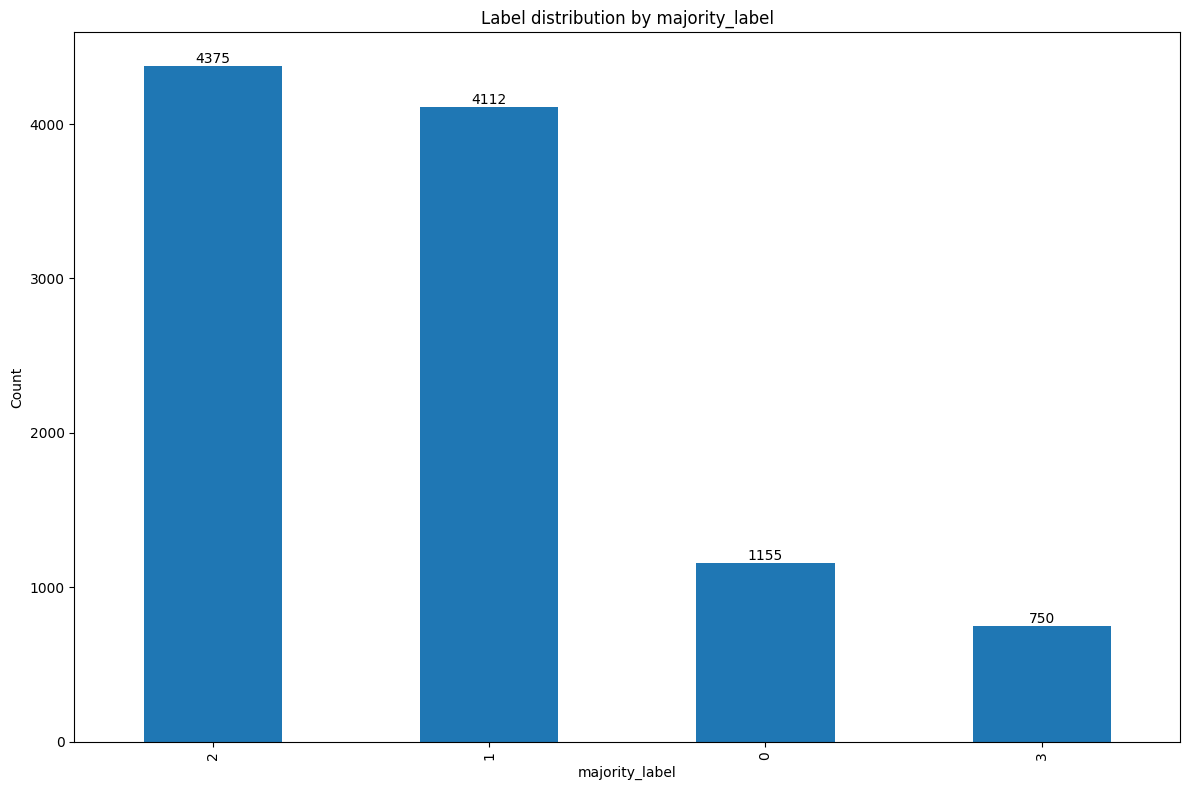

In [17]:
plt.figure(figsize=(12,8))
status_counts = df['ai_pred_label'].value_counts()
ax = status_counts.plot(kind='bar')
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Label distribution by majority_label')
plt.xlabel('majority_label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3.Modeling

## 3.1 Classical ML Model

### 3.1.0 Pre-processing for classical ML Models \& Model Evaluation Functions


#### 3.1.0.1 Data Preprocessing

In [18]:
#make a copy of data especially for classical ML Models
df1 = df.copy()

In [19]:
# Step 1: Clean the Text
# Purpose: Removes noise (e.g., special characters, extra spaces) that doesn't contribute to understanding the text's meaning.
def clean_text(text):
    if pd.isna(text):
        return ""  # or return np.nan if you want to keep missing
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+", "<URL>", text)  # Replace URLs with <URL>
    text = re.sub(r"@\w+", "<USER>", text)   # Replace mentions with <USER>
    text = re.sub(r"#\w+", "<HASHTAG>", text)  # Replace hashtags with <HASHTAG>
    text = re.sub(r"[^\w\s]", "", text)      # Remove special characters
    text = re.sub(r"\s+", " ", text)         # Normalize whitespace
    return text.strip()
df1['posts'] = df1['posts'].apply(clean_text)

In [20]:
#Step 2: stopwords removal
#Stop words (e.g., "and", "is", "the") do not carry much meaning and can be removed to reduce noise.
stop_words = set(stopwords.words('english'))
df1['posts'] = df1['posts'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [21]:
#Step 3：lemmatize
# Reduces words to their base or root forms, ensuring that variations of the same word are treated equally (e.g., "running", "runs", "ran" → "run").
lemmatizer = WordNetLemmatizer()
df1['posts'] = df1['posts'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))


In [22]:
#Step 4: Train-Test Split
#Random sample, use 20% data for test, 80% data for train
X1 = df['posts']
y1 = df['ai_pred_label']
random.seed(1234)
# Initial train-test split
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X1.tolist(), y1.tolist(), test_size=0.2, random_state=42
)

# Further split training data into training and validation sets
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(
    X_train_1, y_train_1, test_size=0.25, random_state=42  # for validation: 0.25 * 0.8 = 0.2 of original data
)

In [23]:
tfidf = TfidfVectorizer(stop_words="english", max_features=10000, ngram_range=(1, 2))

# sanitize: fill NaN -> "", force str
X_train_1 = pd.Series(X_train_1).fillna("").astype(str)
X_val_1   = pd.Series(X_val_1).fillna("").astype(str)
X_test_1  = pd.Series(X_test_1).fillna("").astype(str)

X_train_tfidf_1 = tfidf.fit_transform(X_train_1)
X_val_tfidf_1   = tfidf.transform(X_val_1)
X_test_tfidf_1  = tfidf.transform(X_test_1)

#### 3.1.0.2 Model Evaluation

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    f1_score, classification_report, confusion_matrix
)

def _infer_classes(y_true, classes=None):
    """
    Determine a stable class order.
    If classes is provided, use it. Else use np.unique(y_true) in sorted order.
    """
    if classes is not None:
        return np.array(list(classes))
    return np.unique(np.asarray(y_true))


def _ensure_2d_scores(y_scores, n_classes):
    """
    Ensure y_scores is shape (n_samples, n_classes).
    - If 1D and n_classes==2, convert to 2-column scores: [1-p, p] if looks like proba
      or [-s, s] if looks like decision score.
    - If 2D, validate second dimension.
    """
    y_scores = np.asarray(y_scores)

    if y_scores.ndim == 1:
        if n_classes != 2:
            raise ValueError(f"Got 1D scores but n_classes={n_classes}. Expected 2D scores.")
        s = y_scores
        # Heuristic: if values are within [0,1], treat as positive-class probability
        if np.all((s >= 0) & (s <= 1)):
            return np.vstack([1 - s, s]).T
        # Otherwise treat as decision score
        return np.vstack([-s, s]).T

    if y_scores.ndim != 2:
        raise ValueError(f"y_scores must be 1D or 2D; got shape {y_scores.shape}")

    if y_scores.shape[1] != n_classes:
        raise ValueError(
            f"y_scores has {y_scores.shape[1]} columns but n_classes={n_classes}. "
            "This usually means class ordering / alignment is off."
        )
    return y_scores


def bootstrap_auc_ci_multiclass(
    y_true,
    y_scores,
    classes=None,
    n_iterations=2000,
    average="macro",
    multi_class="ovr",
    ci=95,
    random_state=42,
    min_valid=200,
):
    """
    Bootstrapped CI for multi-class ROC AUC.

    Key improvements vs original:
    - Works with string labels by accepting/inferring `classes`.
    - Enforces alignment between `classes` and y_scores columns (caller must ensure order).
    - Uses a dedicated RNG for reproducibility.
    - Handles empty/low-valid bootstraps safely.
    """
    y_true = np.asarray(y_true)
    classes = _infer_classes(y_true, classes=classes)
    n_classes = len(classes)

    y_scores = _ensure_2d_scores(y_scores, n_classes)
    y_true_bin = label_binarize(y_true, classes=classes)

    rng = np.random.default_rng(random_state)
    n = len(y_true)

    auc_samples = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)  # bootstrap sample indices
        yt = y_true_bin[idx]
        ys = y_scores[idx]

        # Skip samples missing at least one class (common with imbalanced data)
        if yt.sum(axis=0).min() == 0:
            continue

        try:
            auc_val = roc_auc_score(
                yt, ys,
                average=average,
                multi_class=multi_class
            )
            auc_samples.append(auc_val)
        except ValueError:
            continue

    if len(auc_samples) < max(10, min_valid):
        raise RuntimeError(
            f"Too few valid bootstrap samples for AUC CI: {len(auc_samples)}. "
            "Consider increasing n_iterations, using stratified bootstrap, "
            "or ensuring each class has enough test samples."
        )

    auc_samples = np.asarray(auc_samples)
    alpha = (100 - ci) / 2
    return float(auc_samples.mean()), float(np.percentile(auc_samples, alpha)), float(np.percentile(auc_samples, 100 - alpha))


def bootstrap_f1_ci(
    y_true,
    y_pred,
    n_iterations=2000,
    average="weighted",
    ci=95,
    random_state=42,
    min_valid=200,
):
    """
    Bootstrapped CI for F1 score.

    Improvements:
    - Uses dedicated RNG
    - Safeguards against too few valid bootstrap draws
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    f1_samples = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = y_pred[idx]

        # If bootstrap draw collapses labels badly, metrics can be degenerate
        if len(np.unique(yt)) < 2:
            continue

        f1_samples.append(f1_score(yt, yp, average=average))

    if len(f1_samples) < max(10, min_valid):
        raise RuntimeError(
            f"Too few valid bootstrap samples for F1 CI: {len(f1_samples)}. "
            "Consider increasing n_iterations or ensuring enough test samples."
        )

    f1_samples = np.asarray(f1_samples)
    alpha = (100 - ci) / 2
    return float(f1_samples.mean()), float(np.percentile(f1_samples, alpha)), float(np.percentile(f1_samples, 100 - alpha))


def plot_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title="Confusion Matrix"):
    """
    Confusion matrix plot with stable label ordering.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = _infer_classes(y_true, classes=labels)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if normalize:
        cm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_multiclass_roc(y_true, y_scores, classes=None, label_prefix="Model", add_macro=True):
    """
    Multi-class ROC curves (OvR) with optional macro-average curve.

    Improvements:
    - Works with string labels via `classes`
    - Validates score alignment and shape
    """
    y_true = np.asarray(y_true)
    classes = _infer_classes(y_true, classes=classes)
    n_classes = len(classes)

    y_scores = _ensure_2d_scores(y_scores, n_classes)
    y_true_bin = label_binarize(y_true, classes=classes)

    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")

    if add_macro:
        # Macro-average ROC: interpolate mean TPR across unique FPRs
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, lw=3, linestyle="--", label=f"Macro-average (AUC={macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC (OvR)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def evaluate_model_multiclass(model, X_test, y_test, model_name="Model", ci_iters=2000, random_state=42):
    """
    Evaluates a sklearn-like classifier for multi-class classification with:
    - classification report
    - bootstrapped weighted F1 CI
    - confusion matrix
    - bootstrapped macro AUC CI (OvR)
    - ROC plot

    Critical improvement:
    - Uses model.classes_ (if available) to align:
      label binarization + predict_proba/decision_function column order.
    """
    y_test = np.asarray(y_test)

    # Predict labels
    y_pred = model.predict(X_test)

    # Stable class order: prefer model.classes_ to ensure score alignment
    classes = getattr(model, "classes_", None)
    classes = _infer_classes(y_test, classes=classes)

    print(f"\n--- Evaluation Report: {model_name} ---\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # F1 CI
    f1_mean, f1_lo, f1_hi = bootstrap_f1_ci(
        y_test, y_pred,
        n_iterations=ci_iters,
        average="weighted",
        random_state=random_state
    )
    print(f"Weighted F1: {f1_mean:.4f}")
    print(f"95% CI (F1): [{f1_lo:.4f}, {f1_hi:.4f}]")

    # Confusion matrix
    plot_confusion_matrix(y_test, y_pred, labels=classes, normalize=False, title=f"{model_name} - Confusion Matrix")

    # Scores for AUC/ROC
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("Model doesn't support predict_proba or decision_function; skipping AUC/ROC.")
        return

    n_classes = len(classes)
    y_scores = _ensure_2d_scores(y_scores, n_classes)

    # AUC CI
    auc_mean, auc_lo, auc_hi = bootstrap_auc_ci_multiclass(
        y_test, y_scores,
        classes=classes,
        n_iterations=ci_iters,
        average="macro",
        multi_class="ovr",
        random_state=random_state
    )
    print(f"Macro AUC (OvR): {auc_mean:.4f}")
    print(f"95% CI (AUC): [{auc_lo:.4f}, {auc_hi:.4f}]")

    # ROC plot
    plot_multiclass_roc(y_test, y_scores, classes=classes, label_prefix=model_name, add_macro=True)

### 3.1.1 Logistic Regression

In [25]:
random.seed(1234)

# Reduced parameter grid for logistic regression
param_grid = {
    'C': [0.1, 1, 10],                # Regularization strength
    'solver': ['lbfgs', 'saga'],      # Optimization solvers
    'penalty': ['l2'],                # L2 regularization
    'multi_class': ['multinomial'],   # Multiclass strategy: using multinomial for multi-class classification
    'class_weight': ['balanced', None],     # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model = None
best_params = None

# Start timer
start_time = time.time()

# Iterate through reduced parameter grid
for C, solver, penalty, multi_class, class_weight in product(
        param_grid['C'], param_grid['solver'], param_grid['penalty'], param_grid['multi_class'], param_grid['class_weight']):
    try:
        # Create the Logistic Regression model with current parameters
        model = LogisticRegression(
            C=C,
            solver=solver,
            penalty=penalty,
            multi_class=multi_class,
            class_weight=class_weight,
            max_iter=1000,
            random_state=42
        )

        # Train the model
        model.fit(X_train_tfidf_1, y_train_1)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_tfidf_1)
        f1 = f1_score(y_val_1, y_val_pred, average='weighted')  # Multi-class F1-score
        print(f"Validation F1-Score for C={C}, solver={solver}, penalty={penalty}, multi_class={multi_class}, class_weight={class_weight}: {f1:.4f}")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_lr = model
            best_params_lr = {
                'C': C,
                'solver': solver,
                'penalty': penalty,
                'multi_class': multi_class,
                'class_weight': class_weight
            }
    except Exception as e:
        print(f"Skipping combination C={C}, solver={solver}, penalty={penalty}, multi_class={multi_class}, class_weight={class_weight} due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_lr)
print("Best Validation F1-Score:", best_f1)

# ====== SAVE BEST MODEL + PARAMS (GRU-style) ======
if best_model_lr is None:
    raise RuntimeError("No valid LR model was found during tuning.")

# Uses your config paths:
# BEST_LR_PATH, BEST_LR_PARAMS_PATH
joblib.dump(best_model_lr, BEST_LR_PATH)
with open(BEST_LR_PARAMS_PATH, "w") as f:
    json.dump(best_params_lr, f, indent=2)

print(f"Saved best LR model to: {BEST_LR_PATH}")
print(f"Saved best LR params to: {BEST_LR_PARAMS_PATH}")


Validation F1-Score for C=0.1, solver=lbfgs, penalty=l2, multi_class=multinomial, class_weight=balanced: 0.6846
Validation F1-Score for C=0.1, solver=lbfgs, penalty=l2, multi_class=multinomial, class_weight=None: 0.6176
Validation F1-Score for C=0.1, solver=saga, penalty=l2, multi_class=multinomial, class_weight=balanced: 0.6846
Validation F1-Score for C=0.1, solver=saga, penalty=l2, multi_class=multinomial, class_weight=None: 0.6181
Validation F1-Score for C=1, solver=lbfgs, penalty=l2, multi_class=multinomial, class_weight=balanced: 0.7153
Validation F1-Score for C=1, solver=lbfgs, penalty=l2, multi_class=multinomial, class_weight=None: 0.7020
Validation F1-Score for C=1, solver=saga, penalty=l2, multi_class=multinomial, class_weight=balanced: 0.7067
Validation F1-Score for C=1, solver=saga, penalty=l2, multi_class=multinomial, class_weight=None: 0.7033
Validation F1-Score for C=10, solver=lbfgs, penalty=l2, multi_class=multinomial, class_weight=balanced: 0.7157
Validation F1-Score f

In [26]:
LR = LogisticRegression(
    **best_params_lr,
    max_iter=1000,
    random_state=42
)

# Train the model
LR.fit(X_train_tfidf_1, y_train_1)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42, solver='saga')


--- Evaluation Report: Logistic Regression ---

Classification Report:
              precision    recall  f1-score   support

           0     0.6198    0.7075    0.6608       212
           1     0.7350    0.7043    0.7193       886
           2     0.7656    0.7656    0.7656       836
           3     0.4079    0.4276    0.4175       145

    accuracy                         0.7100      2079
   macro avg     0.6321    0.6512    0.6408      2079
weighted avg     0.7127    0.7100    0.7109      2079

Weighted F1: 0.7109
95% CI (F1): [0.6914, 0.7304]


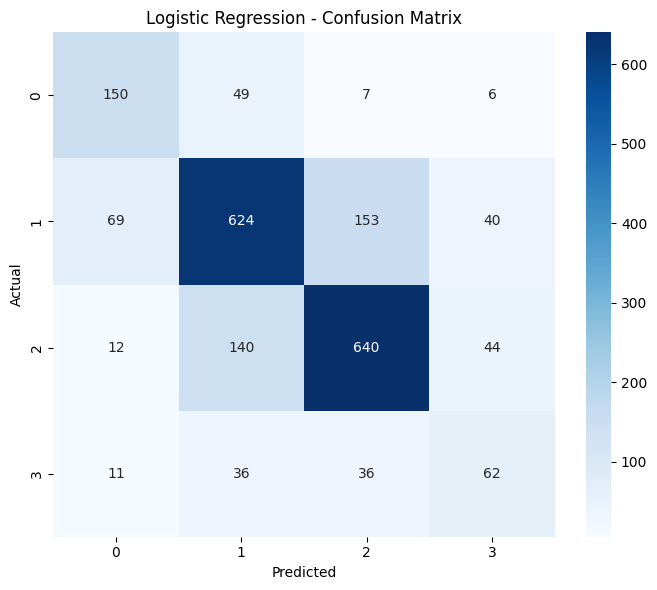

Macro AUC (OvR): 0.8835
95% CI (AUC): [0.8711, 0.8949]


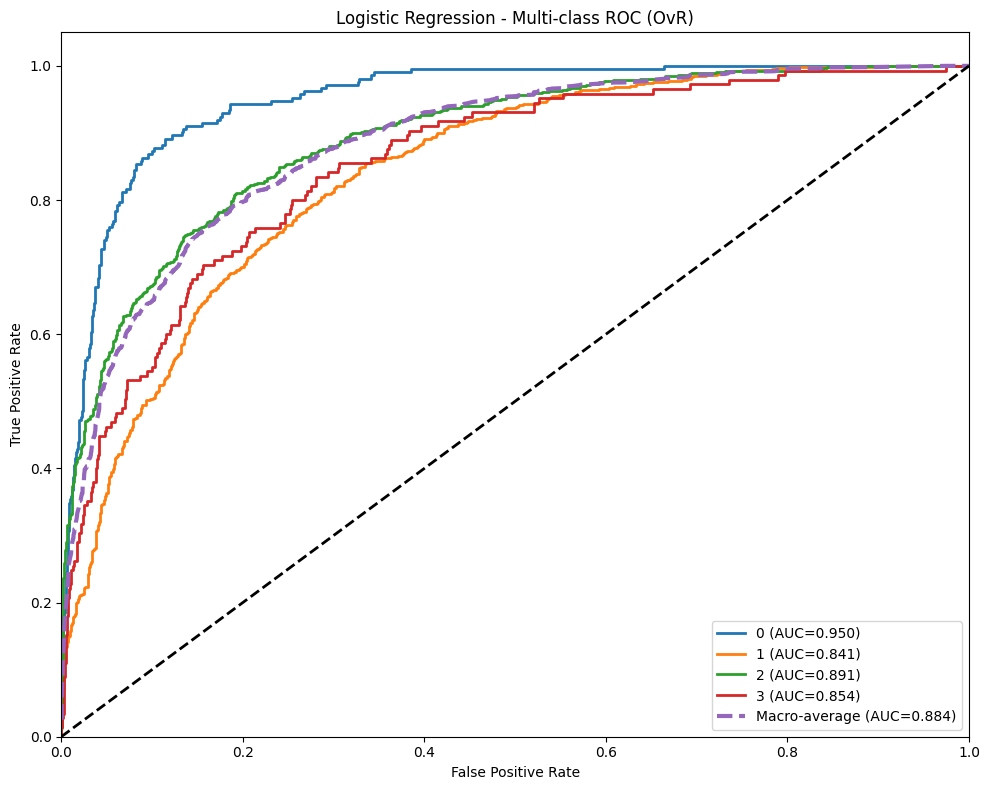

In [27]:
evaluate_model_multiclass(LR, X_test_tfidf_1, y_test_1, model_name="Logistic Regression")


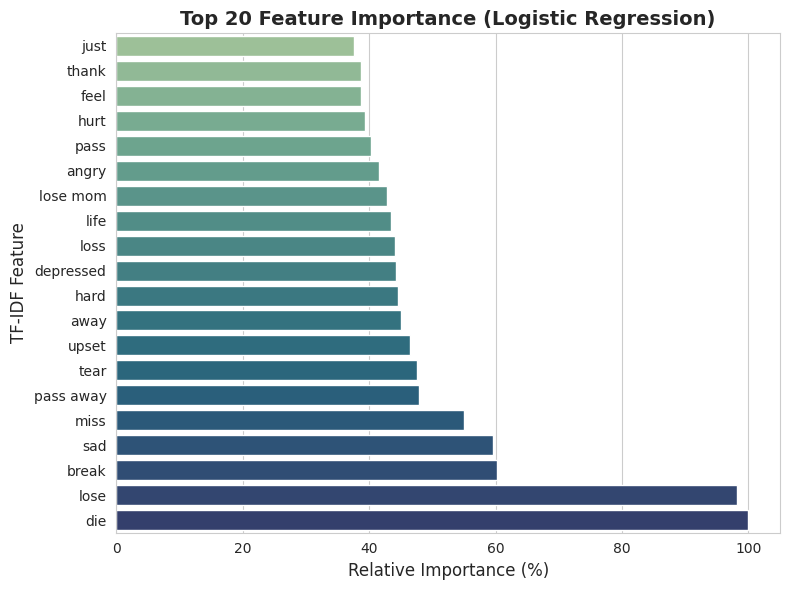

        Feature  Coefficient  Scaled Importance
2541        die     9.011177         100.000000
5315       lose     8.845298          98.159186
1223      break     5.425556          60.209185
7563        sad     5.369437          59.586407
5757       miss     4.961477          55.059147
6475  pass away     4.319269          47.932348
8629       tear     4.291801          47.627534
9366      upset     4.188797          46.484462
851        away     4.058646          45.040135
3834       hard     4.020115          44.612538
2449  depressed     3.992211          44.302882
5340       loss     3.971816          44.076553
4985       life     3.919622          43.497337
5332   lose mom     3.858188          42.815588
647       angry     3.743900          41.547292
6474       pass     3.636398          40.354311
4236       hurt     3.540798          39.293400
3259       feel     3.488097          38.708561
8773      thank    -3.484994          38.674127
4614       just     3.391858          37

In [28]:
# Extract feature names
feature_names = tfidf.get_feature_names_out()

# Extract coefficients from the trained Logistic Regression model
coefficients = LR.coef_[0]

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Use absolute value for importance
importance_df['Importance (Abs)'] = importance_df['Coefficient'].abs()

# Normalize importance (rescale to 0–100)
importance_df['Scaled Importance'] = (
    importance_df['Importance (Abs)'] / importance_df['Importance (Abs)'].max()
) * 100

# Sort and take top 20
top_20_features = importance_df.sort_values(by='Importance (Abs)', ascending=False).head(20)

# Plot (horizontal bar chart)
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
sns.barplot(
    x='Scaled Importance',
    y='Feature',
    data=top_20_features[::-1],  # Reverse for descending top-down
    palette="crest"
)

plt.title("Top 20 Feature Importance (Logistic Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance (%)", fontsize=12)
plt.ylabel("TF-IDF Feature", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save high-res for paper
plt.savefig("top_features_lr.png", dpi=300)
plt.show()

# Optionally print the top 20
print(top_20_features[['Feature', 'Coefficient', 'Scaled Importance']])


### 3.1.2 Random Forest

In [29]:
random.seed(1234)

# Parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],       # Number of trees
    'max_depth': [None, 10, 20],          # Depth of the tree
    'min_samples_split': [2, 5, 10],      # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],        # Minimum samples required at a leaf node
    'class_weight': ['balanced', None],   # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model = None
best_params = None

# Start timer
start_time = time.time()

# Iterate through reduced parameter grid
for n_estimators, max_depth, min_samples_split, min_samples_leaf, class_weight in product(
        param_grid['n_estimators'],
        param_grid['max_depth'],
        param_grid['min_samples_split'],
        param_grid['min_samples_leaf'],
        param_grid['class_weight']):
    try:
        # Create the Random Forest model with current parameters
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight=class_weight,
            random_state=42
        )

        # Train the model
        model.fit(X_train_tfidf_1, y_train_1)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_tfidf_1)
        f1 = f1_score(y_val_1, y_val_pred, average='weighted')  # Multi-class F1-score
        print(f"Validation F1-Score for n_estimators={n_estimators}, max_depth={max_depth}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}, class_weight={class_weight}: {f1:.4f}")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_rf = model
            best_params_rf = {
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'class_weight': class_weight
            }
    except Exception as e:
        print(f"Skipping combination n_estimators={n_estimators}, max_depth={max_depth}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}, class_weight={class_weight} due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_rf)
print("Best Validation F1-Score:", best_f1)

# ====== SAVE BEST MODEL + PARAMS (RF) ======
if best_model_rf is None:
    raise RuntimeError("No valid Random Forest model was found during tuning.")

joblib.dump(best_model_rf, BEST_RF_PATH)
with open(BEST_RF_PARAMS_PATH, "w") as f:
    json.dump(best_params_rf, f, indent=2)

print(f"Saved best RF model to: {BEST_RF_PATH}")
print(f"Saved best RF params to: {BEST_RF_PARAMS_PATH}")

Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight=balanced: 0.6462
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight=None: 0.6353
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=2, class_weight=balanced: 0.6722
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=2, class_weight=None: 0.6372
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=4, class_weight=balanced: 0.6670
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=4, class_weight=None: 0.6166
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=5, min_samples_leaf=1, class_weight=balanced: 0.6603
Validation F1-Score for n_estimators=50, max_depth=None, min_samples_split=5, min_samples_leaf=1, class_weight=None:

In [30]:
# Create the Random Forest model with current parameters
RandomForest = RandomForestClassifier(
    **best_params_rf,
    random_state=42
)

# Train the model
RandomForest.fit(X_train_tfidf_1, y_train_1)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=4,
                       random_state=42)


--- Evaluation Report: RandomForest ---

Classification Report:
              precision    recall  f1-score   support

           0     0.5335    0.7877    0.6362       212
           1     0.6892    0.7009    0.6950       886
           2     0.7620    0.7237    0.7423       836
           3     0.5634    0.2759    0.3704       145

    accuracy                         0.6893      2079
   macro avg     0.6370    0.6220    0.6110      2079
weighted avg     0.6938    0.6893    0.6854      2079

Weighted F1: 0.6853
95% CI (F1): [0.6647, 0.7057]


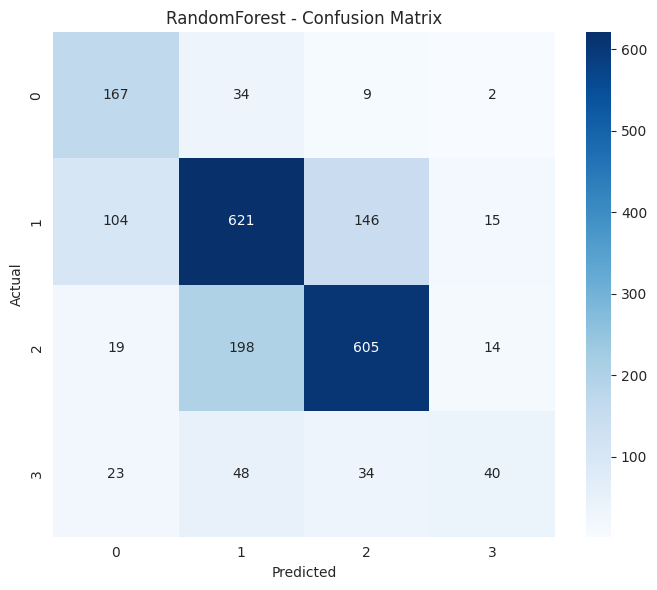

Macro AUC (OvR): 0.8744
95% CI (AUC): [0.8626, 0.8860]


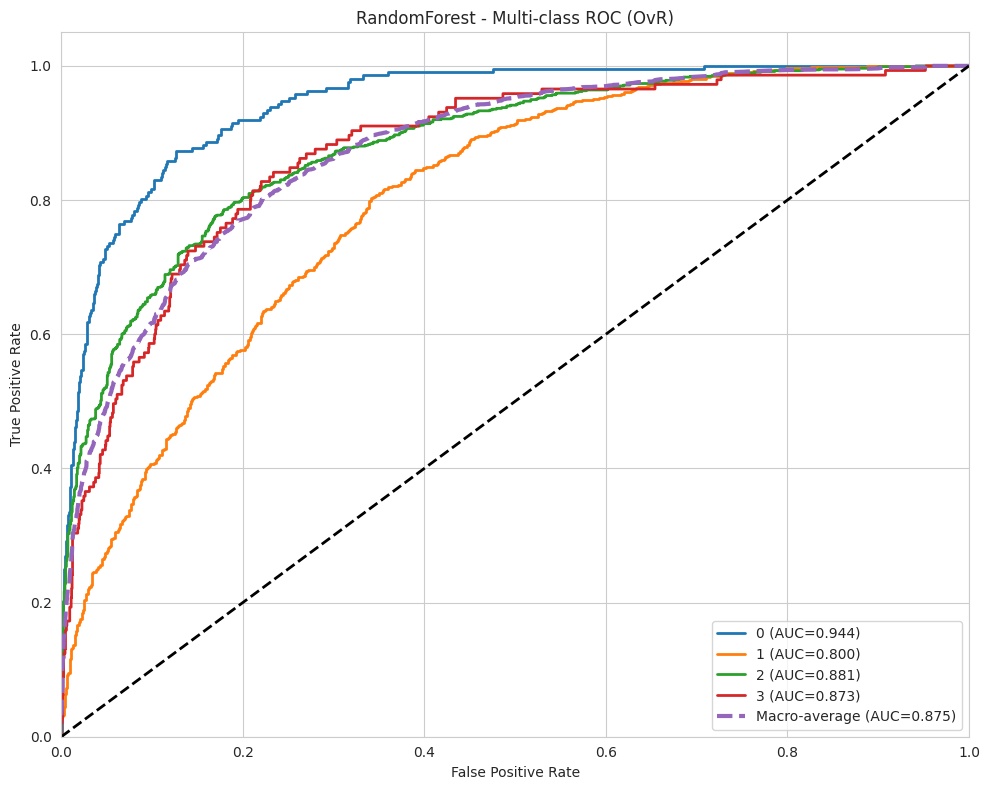

In [31]:
evaluate_model_multiclass(RandomForest, X_test_tfidf_1, y_test_1, model_name="RandomForest")


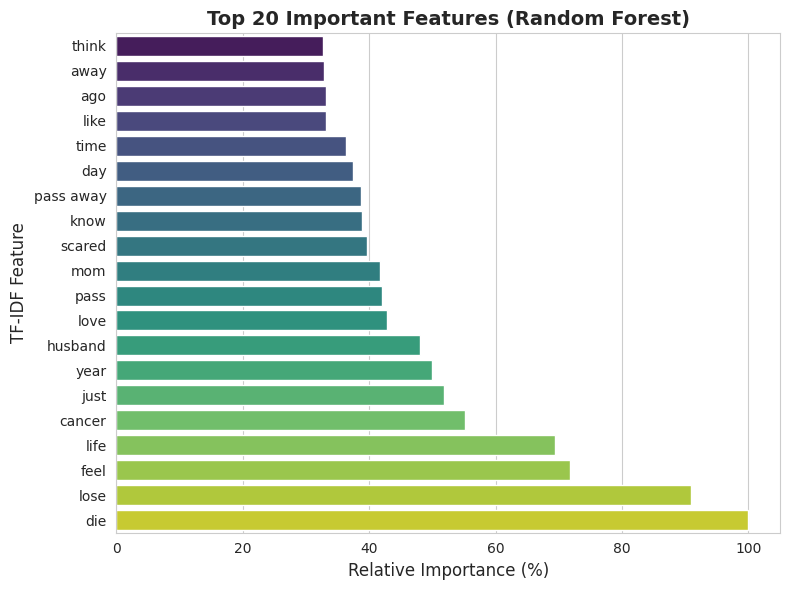

In [32]:
# Ensure the best_model is available after parameter tuning
if RandomForest is not None:
    # Get the feature names from TfidfVectorizer
    feature_names = tfidf.get_feature_names_out()

    # Get the feature importances from the trained Random Forest model
    feature_importance = RandomForest.feature_importances_
    feature_importance = (feature_importance / feature_importance.max()) * 100

    # Map feature importance to feature names
    important_features = sorted(
        zip(feature_importance, feature_names),
        key=lambda x: x[0],
        reverse=True
    )

    # Select top N features
    top_n = 20
    top_features = important_features[:top_n]
    importances, names = zip(*top_features)

    # Reverse for horizontal bar plot
    importances = importances[::-1]
    names = names[::-1]

    # Plot
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x=importances, y=names, palette="viridis")

    plt.title("Top 20 Important Features (Random Forest)", fontsize=14, fontweight='bold')
    plt.xlabel("Relative Importance (%)", fontsize=12)
    plt.ylabel("TF-IDF Feature", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()

    # Save high-res for paper
    plt.savefig("top_features_rf.png", dpi=300)
    plt.show()
else:
    print("No model was trained successfully. Unable to display feature importance.")


### 3.1.3 LGBM

In [33]:
random.seed(1234)

# Parameter grid for LightGBM
param_grid = {
    'n_estimators': [100, 200],          # Number of boosting iterations
    'learning_rate': [0.01, 0.1, 0.2],       # Learning rate
    'num_leaves': [31, 63],              # Maximum number of leaves in a tree
    'max_depth': [None, 10],             # Maximum tree depth
    'class_weight': ['balanced', None],      # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model = None
best_params = None

# Start timer
start_time = time.time()

# Iterate through reduced parameter grid
for n_estimators, learning_rate, num_leaves, max_depth, class_weight in product(
        param_grid['n_estimators'],
        param_grid['learning_rate'],
        param_grid['num_leaves'],
        param_grid['max_depth'],
        param_grid['class_weight']):
    try:
        # Create the LightGBM model with current parameters
        model = LGBMClassifier(
            objective='multiclass',                # Multi-class objective
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            num_leaves=num_leaves,
            max_depth=max_depth,
            class_weight=class_weight,
            random_state=42,
            importance_type='gain'
        )

        # Train the model
        model.fit(X_train_tfidf_1, y_train_1)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_tfidf_1)
        f1 = f1_score(y_val_1, y_val_pred, average='weighted')  # Multi-class F1-score
        print(f"Validation F1-Score for n_estimators={n_estimators}, learning_rate={learning_rate}, num_leaves={num_leaves}, max_depth={max_depth}, class_weight={class_weight}: {f1:.4f}")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_lgbm = model
            best_params_lgbm = {
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
                'num_leaves': num_leaves,
                'max_depth': max_depth,
                'class_weight': class_weight
            }
    except Exception as e:
        print(f"Skipping combination n_estimators={n_estimators}, learning_rate={learning_rate}, num_leaves={num_leaves}, max_depth={max_depth}, class_weight={class_weight} due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_lgbm)
print("Best Validation F1-Score:", best_f1)

# ====== SAVE BEST MODEL + PARAMS (LGBM) ======
if best_model_lgbm is None:
    raise RuntimeError("No valid LightGBM model was found during tuning.")

joblib.dump(best_model_lgbm, BEST_LGBM_PATH)
with open(BEST_LGBM_PARAMS_PATH, "w") as f:
    json.dump(best_params_lgbm, f, indent=2)

print(f"Saved best LGBM model to: {BEST_LGBM_PATH}")
print(f"Saved best LGBM params to: {BEST_LGBM_PARAMS_PATH}")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [34]:
LGBM = LGBMClassifier(
    objective='multiclass',                # Multi-class objective
    **best_params_lgbm,
    random_state=42,
    importance_type='gain'
)

# Train the model
LGBM.fit(X_train_tfidf_1, y_train_1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.265918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 132917
[LightGBM] [Info] Number of data points in the train set: 6234, number of used features: 4215
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


LGBMClassifier(class_weight='balanced', importance_type='gain', max_depth=None,
               n_estimators=200, objective='multiclass', random_state=42)


--- Evaluation Report: LightGBM ---

Classification Report:
              precision    recall  f1-score   support

           0     0.6884    0.6462    0.6667       212
           1     0.7269    0.7540    0.7402       886
           2     0.7634    0.7990    0.7808       836
           3     0.4884    0.2897    0.3636       145

    accuracy                         0.7287      2079
   macro avg     0.6668    0.6222    0.6378      2079
weighted avg     0.7210    0.7287    0.7228      2079

Weighted F1: 0.7226
95% CI (F1): [0.7030, 0.7420]


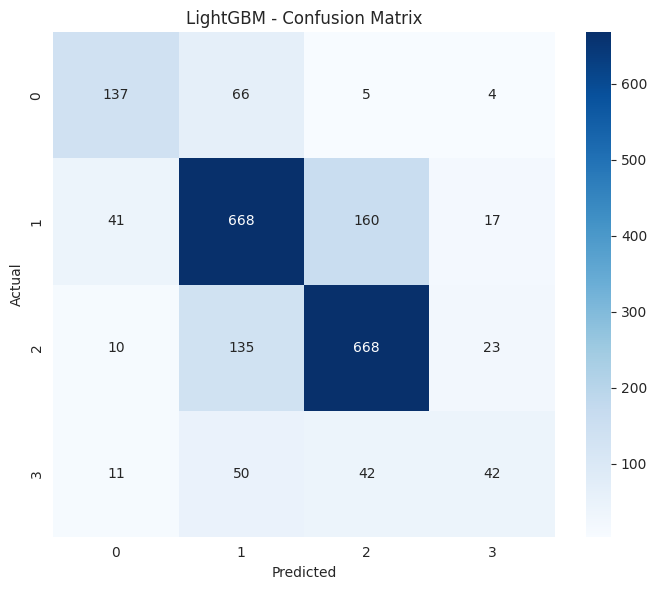

Macro AUC (OvR): 0.8833
95% CI (AUC): [0.8712, 0.8950]


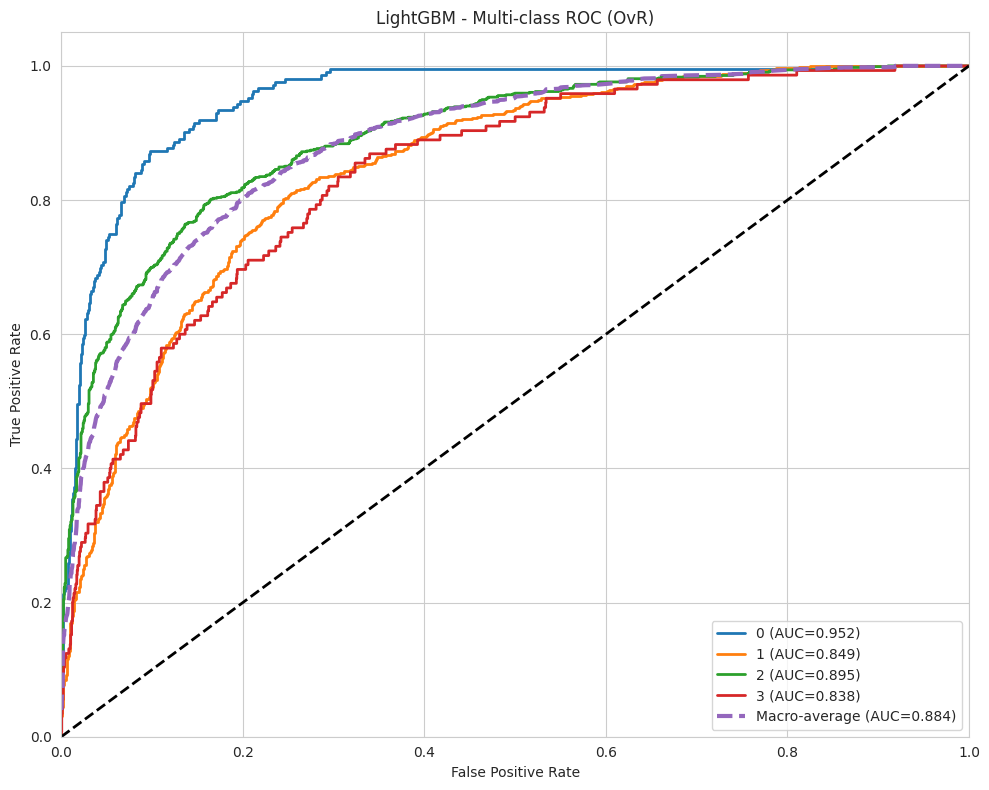

In [35]:
evaluate_model_multiclass(LGBM, X_test_tfidf_1, y_test_1, model_name="LightGBM")


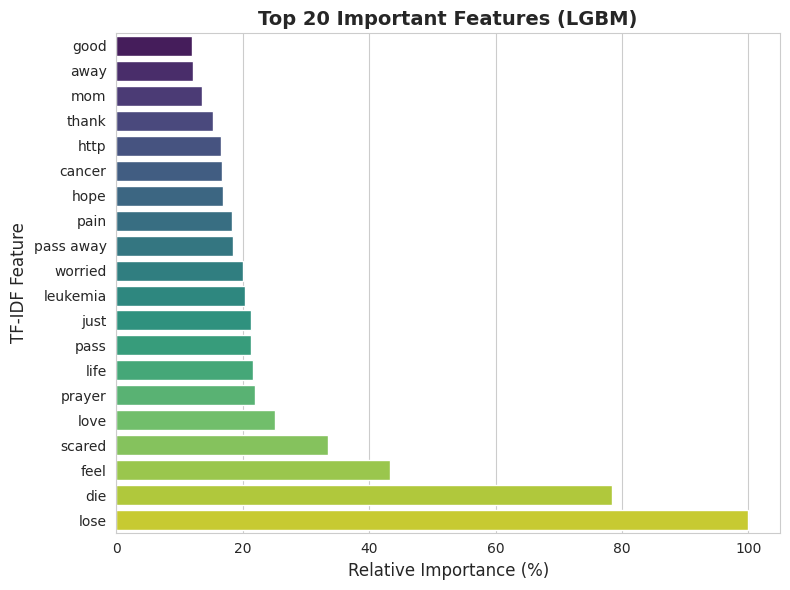

In [36]:
# Ensure the best_model is available after parameter tuning
if LGBM is not None:
    # Get the feature names from TfidfVectorizer
    feature_names = tfidf.get_feature_names_out()

    # Get the feature importances from the trained Random Forest model
    feature_importance = LGBM.feature_importances_
    feature_importance = (feature_importance / feature_importance.max()) * 100

    # Map feature importance to feature names
    important_features = sorted(
        zip(feature_importance, feature_names),
        key=lambda x: x[0],
        reverse=True
    )

    # Select top N features
    top_n = 20
    top_features = important_features[:top_n]
    importances, names = zip(*top_features)

    # Reverse for horizontal bar plot
    importances = importances[::-1]
    names = names[::-1]

    # Plot
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x=importances, y=names, palette="viridis")

    plt.title("Top 20 Important Features (LGBM)", fontsize=14, fontweight='bold')
    plt.xlabel("Relative Importance (%)", fontsize=12)
    plt.ylabel("TF-IDF Feature", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()

    # Save high-res for paper
    plt.savefig("top_features_lgbm.png", dpi=300)
    plt.show()
else:
    print("No model was trained successfully. Unable to display feature importance.")


## 3.2  DL Models


### 3.2.0 Model Evaluation

In [37]:
# ---------------------------
# Helper 1: Bootstrapped F1 CI
# ---------------------------
def bootstrap_f1_ci(
    y_true,
    y_pred,
    n_iterations=2000,
    average="weighted",
    ci=95,
    random_state=42,
    min_valid=200,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rng = np.random.default_rng(random_state)
    n = len(y_true)
    scores = []

    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = y_pred[idx]

        # if bootstrap sample collapses too much, metric can be unstable
        if len(np.unique(yt)) < 2:
            continue

        try:
            scores.append(f1_score(yt, yp, average=average))
        except ValueError:
            continue

    if len(scores) < max(10, min_valid):
        return np.nan, np.nan, np.nan

    scores = np.asarray(scores)
    alpha = (100 - ci) / 2
    return float(scores.mean()), float(np.percentile(scores, alpha)), float(np.percentile(scores, 100 - alpha))


# ---------------------------------
# Helper 2: Bootstrapped Multiclass AUC CI (OvR)
# ---------------------------------
def bootstrap_auc_ci_multiclass(
    y_true,
    y_scores,
    classes,
    n_iterations=2000,
    average="macro",
    multi_class="ovr",
    ci=95,
    random_state=42,
    min_valid=200,
):
    """
    y_true: (n,)
    y_scores: (n, n_classes) probabilities or decision scores
    classes: array-like of class ids in the SAME ORDER as y_scores columns
    """
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    classes = np.asarray(classes)
    n_classes = len(classes)

    if y_scores.ndim != 2 or y_scores.shape[1] != n_classes:
        raise ValueError(f"y_scores must be (n_samples, n_classes={n_classes}), got {y_scores.shape}")

    y_true_bin = label_binarize(y_true, classes=classes)

    rng = np.random.default_rng(random_state)
    n = len(y_true)
    aucs = []

    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        yt = y_true_bin[idx]
        ys = y_scores[idx]

        # skip draws missing at least one class
        if yt.sum(axis=0).min() == 0:
            continue

        try:
            auc_val = roc_auc_score(yt, ys, average=average, multi_class=multi_class)
            aucs.append(auc_val)
        except ValueError:
            continue

    if len(aucs) < max(10, min_valid):
        return np.nan, np.nan, np.nan

    aucs = np.asarray(aucs)
    alpha = (100 - ci) / 2
    return float(aucs.mean()), float(np.percentile(aucs, alpha)), float(np.percentile(aucs, 100 - alpha))


# ---------------------------
# Helper 3: Confusion Matrix Plot
# ---------------------------
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", normalize=False):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ---------------------------
# Helper 4: Multiclass ROC Plot (OvR) + optional Macro curve
# ---------------------------
def plot_multiclass_roc(y_true, y_scores, class_names, label_prefix="Model", add_macro=True):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    n_classes = len(class_names)
    classes = np.arange(n_classes)

    if y_scores.ndim != 2 or y_scores.shape[1] != n_classes:
        raise ValueError(f"y_scores must be (n_samples, n_classes={n_classes}), got {y_scores.shape}")

    y_true_bin = label_binarize(y_true, classes=classes)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})")

    if add_macro:
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, lw=3, linestyle="--", label=f"Macro-average (AUC={macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC (OvR)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# ---------------------------
# Core utility: extract logits robustly
# ---------------------------
def _get_logits(outputs):
    """
    Handles:
    - HF outputs with .logits
    - tuple outputs (logits, ...)
    - raw tensor logits
    """
    if hasattr(outputs, "logits"):
        return outputs.logits
    if isinstance(outputs, (tuple, list)):
        return outputs[0]
    return outputs


# ---------------------------
# Main Evaluation Wrapper (ALBERT + nn.Module)
# ---------------------------
def evaluate_pytorch_model(
    model,
    test_loader,
    device,
    num_classes,
    model_name="Model",
    use_attention_mask=True,
    id2label=None,            # optional: {0:"very negative", ...}
    ci_iters=2000,
    random_state=42,
):
    """
    Works for:
    - Transformers models (AlbertForSequenceClassification, DistilBertForSequenceClassification, etc.)
    - Custom nn.Module models returning logits tensor

    Assumes batch provides:
    - "input_ids"
    - "label"
    - optionally "attention_mask" when use_attention_mask=True
    """

    model.eval()
    model.to(device)

    all_preds, all_probs, all_labels = [], [], []
    softmax = torch.nn.Softmax(dim=1)

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            if use_attention_mask:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                # for GRU-like models that don't use attention_mask
                outputs = model(input_ids)

            logits = _get_logits(outputs)

            # enforce expected shape
            if logits.ndim != 2 or logits.shape[1] != num_classes:
                raise ValueError(
                    f"{model_name}: expected logits shape (batch, {num_classes}), got {tuple(logits.shape)}"
                )

            probs = softmax(logits)
            preds = torch.argmax(probs, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # class names
    if id2label is not None:
        class_names = [id2label[i] for i in range(num_classes)]
    else:
        class_names = [str(i) for i in range(num_classes)]

    print(f"\n--- Evaluation Report: {model_name} ---\n")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # F1 CI
    f1_mean, f1_lo, f1_hi = bootstrap_f1_ci(
        all_labels, all_preds,
        n_iterations=ci_iters,
        average="weighted",
        random_state=random_state
    )
    print(f"Weighted F1: {f1_mean:.4f}")
    print(f"95% CI (F1): [{f1_lo:.4f}, {f1_hi:.4f}]")

    # Confusion matrix
    plot_confusion_matrix(
        all_labels, all_preds,
        class_names=class_names,
        title=f"{model_name} - Confusion Matrix",
        normalize=False
    )

    # AUC CI (macro OvR)
    classes = np.arange(num_classes)
    auc_mean, auc_lo, auc_hi = bootstrap_auc_ci_multiclass(
        all_labels, all_probs,
        classes=classes,
        n_iterations=ci_iters,
        average="macro",
        multi_class="ovr",
        random_state=random_state
    )
    print(f"Macro AUC (OvR): {auc_mean:.4f}")
    print(f"95% CI (AUC): [{auc_lo:.4f}, {auc_hi:.4f}]")

    # ROC curves
    plot_multiclass_roc(all_labels, all_probs, class_names=class_names, label_prefix=model_name, add_macro=True)

    return {
        "y_true": all_labels,
        "y_pred": all_preds,
        "y_prob": all_probs,
        "f1_mean": f1_mean,
        "f1_ci": (f1_lo, f1_hi),
        "auc_mean": auc_mean,
        "auc_ci": (auc_lo, auc_hi),
        "class_names": class_names,
    }

### 3.2.1 Albert

In [38]:
#make a copy especially for ALBERT
df2 = df.copy()

In [39]:
# Pre-processing for ALBERT
def clean_text_Albert(text):
    if pd.isna(text):
        return ""  # or return np.nan if you want to keep missing
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+", "<URL>", text)  # Replace URLs with <URL>
    text = re.sub(r"@\w+", "<USER>", text)   # Replace mentions with <USER>
    text = re.sub(r"#\w+", "<HASHTAG>", text)  # Replace hashtags with <HASHTAG>
    text = re.sub(r"[^\w\s]", "", text)      # Remove special characters
    text = re.sub(r"\s+", " ", text)         # Normalize whitespace
    return text.strip()

df2['posts'] = df2['posts'].apply(clean_text_Albert)

In [40]:
# Initial train-test split: 60% train, 20% test, 20% validation
train_texts_2, test_texts_2, train_labels_2, test_labels_2 = train_test_split(
    df2['posts'].tolist(), df2['ai_pred_label'].tolist(), test_size=0.2, random_state=42
)
train_texts_2, val_texts_2, train_labels_2, val_labels_2 = train_test_split(
    train_texts_2, train_labels_2, test_size=0.25, random_state=42  # 0.25 * 0.8 = 0.2 of original data
)


#Prepare the data for the model
# Load tokenizer
tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')
max_len = 200

# Create Dataset objects
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)  # Ensure texts is a list of strings
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])  # Ensure each text is a string
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset_2 = SentimentDataset(train_texts_2, train_labels_2, tokenizer,max_len)
test_dataset_2 = SentimentDataset(test_texts_2, test_labels_2, tokenizer,max_len)
val_dataset_2 = SentimentDataset(val_texts_2,val_labels_2,tokenizer,max_len)


# Create DataLoaders
train_loader_2 = DataLoader(train_dataset_2, batch_size=32, shuffle=True)
val_loader_2 = DataLoader(val_dataset_2,batch_size = 32)
test_loader_2 = DataLoader(test_dataset_2, batch_size=32)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

In [41]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def random_hyperparameter_tuning(train_texts, train_labels, val_texts, val_labels, tokenizer, n_iter=10):
    # Define hyperparameter ranges
    param_space = {
        'lr': (np.log10(1e-5), np.log10(1e-4)),              # Learning rate range
        'epochs': (3, 5),                # Epoch range
        'dropout': (0.0, 0.25)           # Dropout rate range
    }

    best_f1 = 0
    best_params = None
    best_model = None

    # Compute class weights for class imbalance
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    # Progress bar for random search iterations
    with tqdm(total=n_iter, desc="Random Search Tuning", leave=True) as pbar:
        for _ in range(n_iter):
            # Randomly sample hyperparameters
            hyperparams = {
                'lr': 10**np.random.uniform(*param_space['lr']),
                'epochs': np.random.randint(*param_space['epochs']),
                'dropout': np.random.uniform(*param_space['dropout'])
            }

            # Initialize model with dropout
            model = AlbertForSequenceClassification.from_pretrained(
                'albert-base-v2',
                num_labels=NUM_CLASSES,
                hidden_dropout_prob=hyperparams['dropout']
            ).to(device)

            optimizer = AdamW(model.parameters(), lr=hyperparams['lr'])
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

            # Training loop
            for epoch in range(hyperparams['epochs']):
                model.train()
                for batch in train_loader_2:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['label'].to(device)

                    optimizer.zero_grad()
                    outputs = model(input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs.logits, labels)
                    loss.backward()
                    optimizer.step()

            # Validation evaluation
            model.eval()
            val_predictions, val_labels_batch = [], []
            with torch.no_grad():
                for batch in val_loader_2:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['label'].to(device)

                    outputs = model(input_ids, attention_mask=attention_mask)
                    preds = torch.argmax(outputs.logits, dim=1)
                    val_predictions.extend(preds.cpu().numpy())
                    val_labels_batch.extend(labels.cpu().numpy())

            # Calculate F1-score
            f1 = f1_score(val_labels_batch, val_predictions, average='weighted')
            accuracy = accuracy_score(val_labels_batch, val_predictions)

            # Update best model
            if f1 > best_f1:
                best_f1 = f1
                best_params = hyperparams
                best_model = model
                # Save the best model
                model_save_path = BEST_ALBERT_PATH
                torch.save(model.state_dict(), model_save_path)

            # Update progress bar
            pbar.set_postfix(f1=f1, accuracy=accuracy)
            pbar.update(1)

    print(f"Best F1 Score: {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")
    return best_params, best_f1, best_model

#Start timer
start_time = time.time()
best_params, best_f1, best_model = random_hyperparameter_tuning(
    train_texts=train_texts_2,
    train_labels=train_labels_2,
    val_texts=val_texts_2,
    val_labels=val_labels_2,
    tokenizer=tokenizer,
    n_iter=10
)
# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")


Random Search Tuning:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Random Search Tuning:  10%|█         | 1/10 [11:37<1:44:39, 697.72s/it, accuracy=0.635, f1=0.651]

...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Random Search Tuning:  90%|█████████ | 9/10 [2:06:46<13:48, 828.63s/it, accuracy=0.411, f1=0.389]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Random Search Tuning: 100%|██████████| 10/10 [2:22:03<00:00, 852.34s/it, accuracy=0.104, f1=0.0196]

Best F1 Score: 0.7691
Best Hyperparameters: {'lr': 1.1974181267700197e-05, 'epochs': 4, 'dropout': 0.06214965916767748}
Total Parameter Tuning Time: 8523.65 seconds


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating ALBERT: 100%|██████████| 65/65 [00:27<00:00,  2.33it/s]



--- Evaluation Report: ALBERT ---

Classification Report:
              precision    recall  f1-score   support

           0     0.7130    0.7736    0.7421       212
           1     0.8253    0.7144    0.7659       886
           2     0.8354    0.8014    0.8181       836
           3     0.3893    0.7517    0.5129       145

    accuracy                         0.7581      2079
   macro avg     0.6908    0.7603    0.7097      2079
weighted avg     0.7875    0.7581    0.7668      2079

Weighted F1: 0.7667
95% CI (F1): [0.7487, 0.7845]


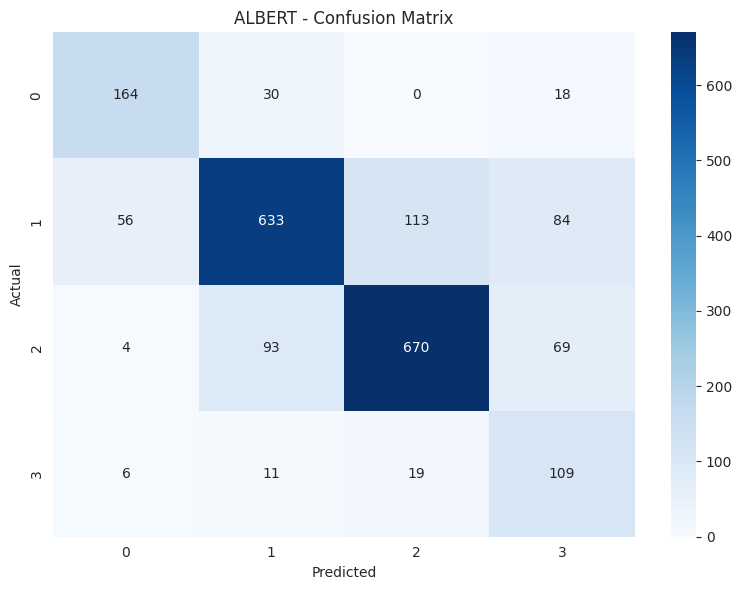

Macro AUC (OvR): 0.9312
95% CI (AUC): [0.9227, 0.9391]


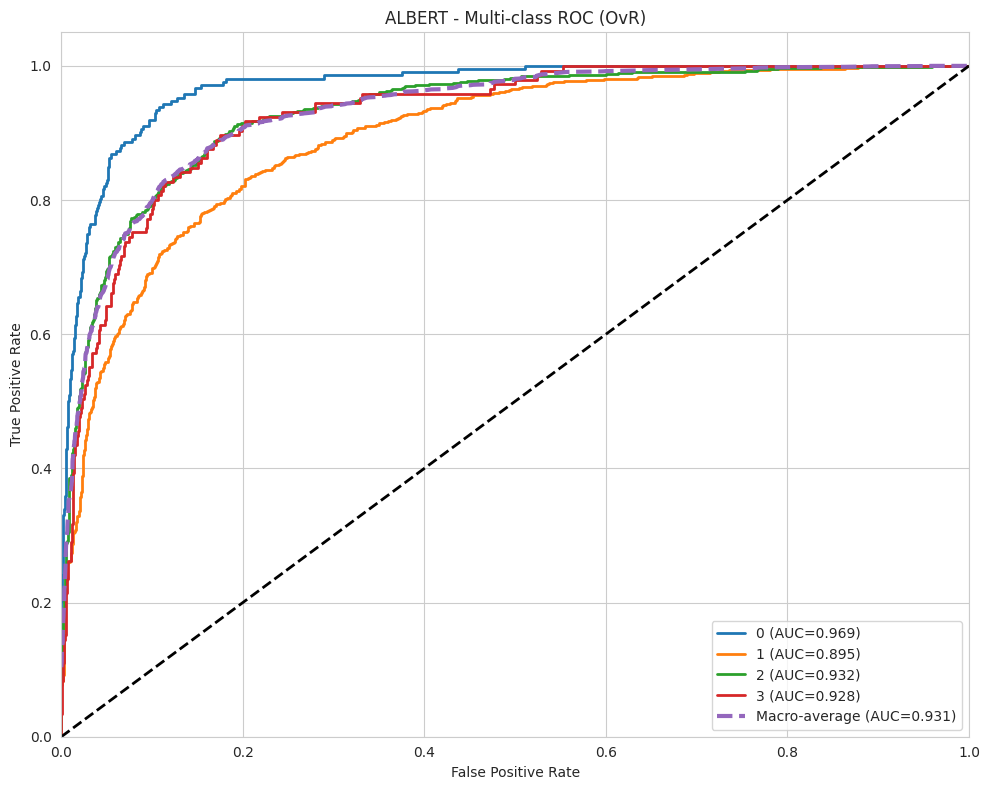

{'y_true': array([1, 1, 1, ..., 2, 3, 3]),
 'y_pred': array([1, 1, 2, ..., 3, 3, 3]),
 'y_prob': array([[0.01065114, 0.40933785, 0.31165412, 0.26835683],
        [0.00780943, 0.4905574 , 0.34662884, 0.15500428],
        [0.00356839, 0.08196297, 0.86659163, 0.04787697],
        ...,
        [0.01199167, 0.02806958, 0.02183005, 0.93810874],
        [0.00710876, 0.06452335, 0.14180812, 0.78655976],
        [0.00514023, 0.00973236, 0.03576241, 0.94936496]], dtype=float32),
 'f1_mean': 0.7667197690365974,
 'f1_ci': (0.7486522030366423, 0.7844796031486061),
 'auc_mean': 0.9311512553383786,
 'auc_ci': (0.9227078731205836, 0.9391465049909825),
 'class_names': ['0', '1', '2', '3']}

In [42]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model and tokenizer with the same config as during training
model = AlbertForSequenceClassification.from_pretrained("albert-base-v2", num_labels=NUM_CLASSES)
model.load_state_dict(torch.load(BEST_ALBERT_PATH, map_location = device))
model.to(device)

tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")


# Evaluation
model.eval()
test_predictions, test_labels_batch, test_probabilities = [], [], []

with torch.no_grad():
    for batch in test_loader_2:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        test_predictions.extend(preds.cpu().numpy())
        test_labels_batch.extend(labels.cpu().numpy())
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        test_probabilities.extend(probs.cpu().numpy())
evaluate_pytorch_model(model, test_loader_2, device, model_name="ALBERT", num_classes=NUM_CLASSES, use_attention_mask=True)


### 3.2.2 BioBERT

In [43]:
# Make a copy especially for BioBERT.
# This uses the same normalized text field and split logic as ALBERT for direct comparison.
df4 = df.copy()

def clean_text_BioBERT(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#\w+", "<HASHTAG>", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df4['posts'] = df4['posts'].apply(clean_text_BioBERT)

In [44]:
# Initial train-test split: same 60/20/20 pattern used for ALBERT and the classical models.
train_texts_4, test_texts_4, train_labels_4, test_labels_4 = train_test_split(
    df4['posts'].tolist(), df4['ai_pred_label'].tolist(), test_size=0.2, random_state=42
)
train_texts_4, val_texts_4, train_labels_4, val_labels_4 = train_test_split(
    train_texts_4, train_labels_4, test_size=0.25, random_state=42
)

# Load BioBERT tokenizer.
biobert_tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
max_len = 200

class BioBERTSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset_4 = BioBERTSentimentDataset(train_texts_4, train_labels_4, biobert_tokenizer, max_len)
val_dataset_4 = BioBERTSentimentDataset(val_texts_4, val_labels_4, biobert_tokenizer, max_len)
test_dataset_4 = BioBERTSentimentDataset(test_texts_4, test_labels_4, biobert_tokenizer, max_len)

train_loader_4 = DataLoader(train_dataset_4, batch_size=32, shuffle=True)
val_loader_4 = DataLoader(val_dataset_4, batch_size=32)
test_loader_4 = DataLoader(test_dataset_4, batch_size=32)

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

In [45]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def random_hyperparameter_tuning_biobert(train_labels, n_iter=10):
    param_space = {
        'lr': (np.log10(1e-5), np.log10(1e-4)),
        'epochs': (3, 5),
        'dropout': (0.0, 0.25),
    }

    best_f1 = 0
    best_params = None
    best_model = None

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(NUM_CLASSES),
        y=np.asarray(train_labels)
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    with tqdm(total=n_iter, desc="BioBERT Random Search", leave=True) as pbar:
        for _ in range(n_iter):
            hyperparams = {
                'lr': 10**np.random.uniform(*param_space['lr']),
                'epochs': np.random.randint(*param_space['epochs']),
                'dropout': np.random.uniform(*param_space['dropout']),
            }

            model = AutoModelForSequenceClassification.from_pretrained(
                BIOBERT_MODEL_NAME,
                num_labels=NUM_CLASSES,
                hidden_dropout_prob=hyperparams['dropout'],
                attention_probs_dropout_prob=hyperparams['dropout'],
            ).to(device)

            optimizer = AdamW(model.parameters(), lr=hyperparams['lr'])
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

            for epoch in range(hyperparams['epochs']):
                model.train()
                for batch in train_loader_4:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['label'].to(device)

                    optimizer.zero_grad()
                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )
                    loss = criterion(outputs.logits, labels)
                    loss.backward()
                    optimizer.step()

            model.eval()
            val_predictions, val_labels_batch = [], []
            with torch.no_grad():
                for batch in val_loader_4:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['label'].to(device)

                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )
                    preds = torch.argmax(outputs.logits, dim=1)

                    val_predictions.extend(preds.cpu().numpy())
                    val_labels_batch.extend(labels.cpu().numpy())

            f1 = f1_score(val_labels_batch, val_predictions, average='weighted')
            accuracy = accuracy_score(val_labels_batch, val_predictions)

            if f1 > best_f1:
                best_f1 = f1
                best_params = hyperparams
                best_model = model
                torch.save(model.state_dict(), BEST_BIOBERT_PATH)
                with open(BEST_BIOBERT_PARAMS_PATH, "w") as f:
                    json.dump(best_params, f, indent=2)

            pbar.set_postfix(f1=f1, accuracy=accuracy)
            pbar.update(1)

    print(f"Best BioBERT F1 Score: {best_f1:.4f}")
    print(f"Best BioBERT Hyperparameters: {best_params}")
    return best_params, best_f1, best_model

start_time = time.time()
best_params_biobert, best_f1_biobert, best_model_biobert = random_hyperparameter_tuning_biobert(
    train_labels=train_labels_4,
    n_iter=10,
)
end_time = time.time()
print(f"Total BioBERT Parameter Tuning Time: {end_time - start_time:.2f} seconds")

BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s][transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

Best BioBERT F1 Score: 0.7636
Best BioBERT Hyperparameters: {'lr': 1.1974181267700197e-05, 'epochs': 4, 'dropout': 0.06214965916767748}
Total BioBERT Parameter Tuning Time: 8212.26 seconds


[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those


--- Evaluation Report: BioBERT ---

Classification Report:
              precision    recall  f1-score   support

           0     0.6589    0.8019    0.7234       212
           1     0.7882    0.7393    0.7630       886
           2     0.8252    0.8074    0.8162       836
           3     0.4535    0.5379    0.4921       145

    accuracy                         0.7590      2079
   macro avg     0.6814    0.7216    0.6987      2079
weighted avg     0.7665    0.7590    0.7614      2079

Weighted F1: 0.7613
95% CI (F1): [0.7431, 0.7794]


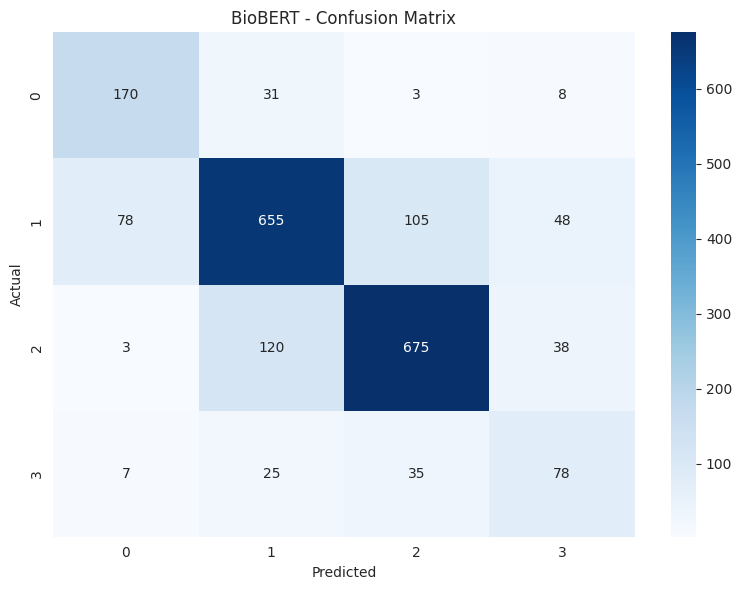

Macro AUC (OvR): 0.9170
95% CI (AUC): [0.9070, 0.9271]


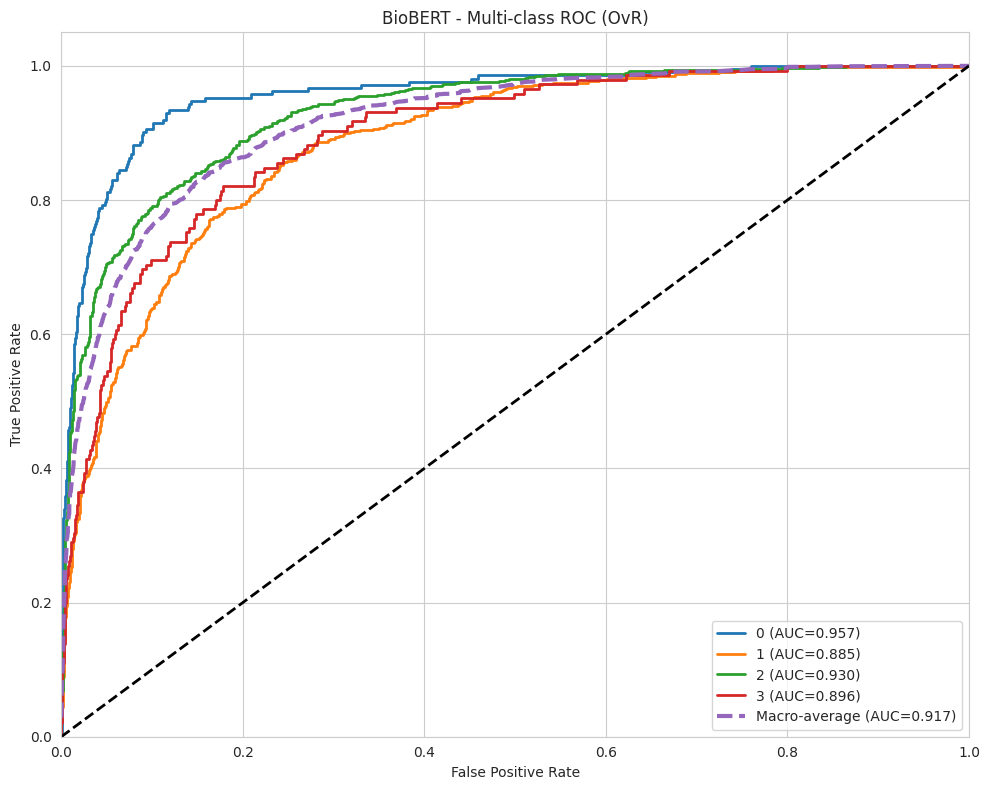

{'y_true': array([1, 1, 1, ..., 2, 3, 3]),
 'y_pred': array([2, 3, 1, ..., 1, 3, 3]),
 'y_prob': array([[0.00226275, 0.21743742, 0.6540881 , 0.12621184],
        [0.0117834 , 0.05488363, 0.00984829, 0.92348456],
        [0.00306062, 0.5047068 , 0.47645372, 0.01577881],
        ...,
        [0.02017791, 0.7762246 , 0.01616879, 0.18742874],
        [0.00949778, 0.12182166, 0.26556677, 0.60311383],
        [0.00306512, 0.0027137 , 0.01623866, 0.9779825 ]], dtype=float32),
 'f1_mean': 0.7612564324988689,
 'f1_ci': (0.74310704530208, 0.7794415694259752),
 'auc_mean': 0.9170056585617175,
 'auc_ci': (0.9069858090680134, 0.9271133079616131),
 'class_names': ['0', '1', '2', '3']}

In [46]:
# Load the best BioBERT model and evaluate on the held-out test set.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

biobert_model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
).to(device)

biobert_model.load_state_dict(torch.load(BEST_BIOBERT_PATH, map_location=device))

biobert_tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_NAME)

evaluate_pytorch_model(
    biobert_model,
    test_loader_4,
    device,
    model_name="BioBERT",
    num_classes=NUM_CLASSES,
    use_attention_mask=True,
)

### 3.2.3 GRU

In [47]:
#copy for GRU
df3 = df.copy()

In [48]:
# Pre-processing for GRU - still minimal
def clean_text_GRU(text):
    if pd.isna(text):
        return ""  # or return np.nan if you want to keep missing
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+", "<URL>", text)  # Replace URLs
    text = re.sub(r"@\w+", "<USER>", text)   # Replace mentions
    text = re.sub(r"#\w+", "<HASHTAG>", text)  # Replace hashtags
    text = re.sub(r"[^\w\s]", "", text)      # Remove special characters
    text = re.sub(r"\s+", " ", text)         # Normalize whitespace
    return text.strip()

df3['posts'] = df3['posts'].apply(clean_text_GRU)

In [49]:
# Hyperparameters
MAX_LEN = 200  # Maximum sequence length
VOCAB_SIZE = 10000  # Vocabulary size
BATCH_SIZE = 16

# Split Dataset
# Initial train-test split
train_texts_3, test_texts_3, train_labels_3, test_labels_3 = train_test_split(
    df3['posts'].tolist(), df3['ai_pred_label'].tolist(), test_size=0.2, random_state=42
)
# Further split training data into training and validation sets
train_texts_3, val_texts_3, train_labels_3, val_labels_3 = train_test_split(
    train_texts_3, train_labels_3, test_size=0.25, random_state=42  # 0.25 * 0.8 = 0.2 of original data
)

# **MODIFIED**: Build Vocabulary after the train-validation-test split
# Build Vocabulary on Training Data Only
all_train_words = " ".join(train_texts_3).split()
most_common_words = [word for word, _ in Counter(all_train_words).most_common(VOCAB_SIZE - 1)]
word_to_index = {word: idx + 1 for idx, word in enumerate(most_common_words)}

# Text-to-Sequence Conversion
def text_to_sequence(text, word_to_index, max_len=MAX_LEN):
    tokens = text.split()
    sequence = [word_to_index.get(word, 0) for word in tokens]
    return sequence[:max_len]

# Convert text to sequences for train, validation, and test sets
train_sequences_3 = [text_to_sequence(text, word_to_index) for text in train_texts_3]
val_sequences_3 = [text_to_sequence(text, word_to_index) for text in val_texts_3]
test_sequences_3 = [text_to_sequence(text, word_to_index) for text in test_texts_3]

# Pad Sequences
train_sequences_3 = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in train_sequences_3], batch_first=True, padding_value=0)
val_sequences_3 = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in val_sequences_3], batch_first=True, padding_value=0)
test_sequences_3 = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in test_sequences_3], batch_first=True, padding_value=0)

# Convert Labels
train_labels_3 = torch.tensor(train_labels_3, dtype=torch.long)
val_labels_3 = torch.tensor(val_labels_3, dtype=torch.long)
test_labels_3 = torch.tensor(test_labels_3, dtype=torch.long)

# Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.texts[idx],
            'label': self.labels[idx]
        }

# Create Datasets and DataLoaders
train_dataset_3 = SentimentDataset(train_sequences_3, train_labels_3)
val_dataset_3 = SentimentDataset(val_sequences_3, val_labels_3)
test_dataset_3 = SentimentDataset(test_sequences_3, test_labels_3)

train_loader_3 = DataLoader(train_dataset_3, batch_size=BATCH_SIZE, shuffle=True)
val_loader_3 = DataLoader(val_dataset_3, batch_size=BATCH_SIZE)
test_loader_3 = DataLoader(test_dataset_3, batch_size=BATCH_SIZE)

In [50]:
# Define GRU Model
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRUSentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)  # Only last hidden state
        output = self.fc(self.dropout(hidden[-1]))
        return output  # **MODIFIED**: Removed `softmax` because `CrossEntropyLoss` expects raw logits


In [51]:
random.seed(1234)

def train_and_evaluate(hyperparams, train_loader, val_loader, vocab_size, output_dim, device):
    embedding_dim = int(hyperparams['embedding_dim'])
    hidden_dim = int(hyperparams['hidden_dim'])
    lr = hyperparams['lr']
    # alpha = hyperparams['alpha']
    # gamma = hyperparams['gamma']

    # Initialize the model, loss, and optimizer
    model = GRUSentimentModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)

    # **MODIFIED**: Compute class weights for the training set
    all_train_labels = [label for batch in train_loader for label in batch['label'].numpy()]
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(all_train_labels),
        y=all_train_labels
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)  # Convert to PyTorch tensor

    # **MODIFIED**: Use CrossEntropyLoss with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training loop
    for epoch in range(hyperparams['epochs']):
        model.train()
        total_loss = 0
        train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{hyperparams['epochs']}", leave=True, position=0)
        for batch in train_loop:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)  # **MODIFIED**: Use CrossEntropyLoss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            train_loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch + 1}/{hyperparams['epochs']}, Loss: {total_loss / len(train_loader):.4f}")

    # Validation evaluation
    model.eval()
    val_predictions, val_labels = [], []
    val_loop = tqdm(val_loader, desc="Validating", leave=True, position=0)
    with torch.no_grad():
        for batch in val_loop:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)
            val_predictions.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # Calculate F1 score and accuracy
    f1 = f1_score(val_labels, val_predictions, average='weighted')
    accuracy = accuracy_score(val_labels, val_predictions)
    print(f"Validation F-1 Score: {f1:.4f}, Accuracy: {accuracy:.4f}")
    return f1, accuracy, model


def random_hyperparameter_tuning(train_loader, val_loader, vocab_size, output_dim, device, n_iter=20):
    # Define hyperparameter ranges for random search
    param_space = {
        'embedding_dim': (150, 250),
        'hidden_dim': (256, 768),
        'lr': (np.log10(1e-4), np.log10(1e-3)),  # Log-uniform for learning rate
        'epochs': (5, 10),  # **MODIFIED**: Removed `alpha` and `gamma` since FocalLoss is no longer used
    }

    best_f1 = 0
    best_params = None
    best_model = None

    # Random search iterations
    with tqdm(total=n_iter, desc="Random Search Tuning", leave=True, position=0) as pbar:
        for _ in range(n_iter):
            # Sample hyperparameters
            hyperparams = {
                'embedding_dim': np.random.uniform(*param_space['embedding_dim']),
                'hidden_dim': np.random.uniform(*param_space['hidden_dim']),
                'lr': 10**np.random.uniform(*param_space['lr']),
                'epochs': np.random.randint(*param_space['epochs']),
            }
            f1, accuracy, model = train_and_evaluate(hyperparams, train_loader, val_loader, vocab_size, output_dim, device)
            pbar.set_postfix(f1=f1, accuracy=accuracy)
            pbar.update(1)

            if f1 > best_f1:
                best_f1 = f1
                best_params = hyperparams
                best_model = model

    print(f"Best Validation F1 Score: {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")

    # Save best model + params
    torch.save(best_model.state_dict(), BEST_GRU_PATH)
    with open(BEST_GRU_PARAMS_PATH, "w") as f:
        json.dump(best_params, f)

    return best_params, best_f1, best_model

#Start timer
start_time = time.time()
# Run random search
best_params, best_f1, best_model= random_hyperparameter_tuning(
    train_loader_3,
    val_loader_3,
    vocab_size=VOCAB_SIZE,
    output_dim=NUM_CLASSES,
    device=device,
    n_iter=10  # Number of random samples to evaluate
)
# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")




Training Epoch 1/6: 100%|██████████| 390/390 [00:06<00:00, 62.25it/s, loss=1.53]


Epoch 1/6, Loss: 1.4045


Training Epoch 2/6: 100%|██████████| 390/390 [00:06<00:00, 64.52it/s, loss=1.06]


Epoch 2/6, Loss: 1.3376


Training Epoch 3/6: 100%|██████████| 390/390 [00:06<00:00, 64.06it/s, loss=1.03]


...

Epoch 5/6, Loss: 0.9526


Training Epoch 6/6: 100%|██████████| 390/390 [00:07<00:00, 52.72it/s, loss=0.693]


Epoch 6/6, Loss: 0.8678


Random Search Tuning: 100%|██████████| 10/10 [12:23<00:00, 74.36s/it, accuracy=0.622, f1=0.619]


Validation F-1 Score: 0.6190, Accuracy: 0.6219
Best Validation F1 Score: 0.7007
Best Hyperparameters: {'embedding_dim': 158.07200956935426, 'hidden_dim': 766.1709261958285, 'lr': 0.0006774290107270521, 'epochs': 9}
Total Parameter Tuning Time: 745.22 seconds


In [52]:
train_loader = train_loader_3
val_loader = val_loader_3
vocab_size=VOCAB_SIZE
output_dim=NUM_CLASSES
hyperparams = best_params
embedding_dim = int(hyperparams['embedding_dim'])
hidden_dim = int(hyperparams['hidden_dim'])
lr = hyperparams['lr']
# alpha = hyperparams['alpha']
# gamma = hyperparams['gamma']

# Initialize the model, loss, and optimizer
model = GRUSentimentModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)

# **MODIFIED**: Compute class weights for the training set
all_train_labels = [label for batch in train_loader for label in batch['label'].numpy()]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_train_labels),
    y=all_train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)  # Convert to PyTorch tensor

# **MODIFIED**: Use CrossEntropyLoss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Training loop
for epoch in range(hyperparams['epochs']):
    model.train()
    total_loss = 0
    train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{hyperparams['epochs']}", leave=True, position=0)
    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels)  # **MODIFIED**: Use CrossEntropyLoss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

        train_loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch + 1}/{hyperparams['epochs']}, Loss: {total_loss / len(train_loader):.4f}")

Training Epoch 1/9: 100%|██████████| 390/390 [00:14<00:00, 26.56it/s, loss=1.48]


Epoch 1/9, Loss: 1.3922


Training Epoch 2/9: 100%|██████████| 390/390 [00:14<00:00, 26.59it/s, loss=1.04]


Epoch 2/9, Loss: 1.1012


Training Epoch 3/9: 100%|██████████| 390/390 [00:14<00:00, 26.43it/s, loss=0.988]


...

Epoch 7/9, Loss: 0.1163


Training Epoch 8/9: 100%|██████████| 390/390 [00:14<00:00, 26.58it/s, loss=0.183]


Epoch 8/9, Loss: 0.0607


Training Epoch 9/9: 100%|██████████| 390/390 [00:14<00:00, 26.52it/s, loss=0.00204]

Epoch 9/9, Loss: 0.0398


Evaluating GRU: 100%|██████████| 130/130 [00:02<00:00, 57.96it/s]



--- Evaluation Report: GRU ---

Classification Report:
              precision    recall  f1-score   support

           0     0.6984    0.6226    0.6584       212
           1     0.6849    0.7506    0.7162       886
           2     0.7873    0.7440    0.7651       836
           3     0.3566    0.3172    0.3358       145

    accuracy                         0.7047      2079
   macro avg     0.6318    0.6086    0.6188      2079
weighted avg     0.7046    0.7047    0.7034      2079

Weighted F1: 0.7032
95% CI (F1): [0.6837, 0.7224]


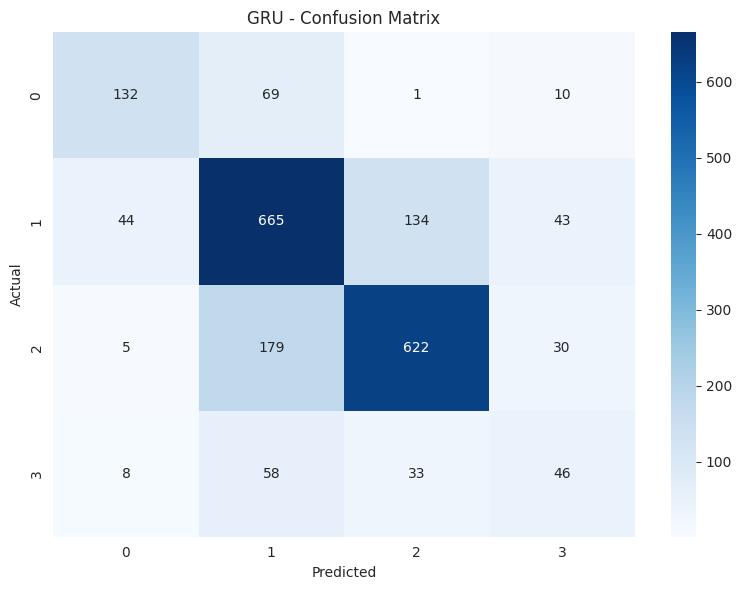

Macro AUC (OvR): 0.8555
95% CI (AUC): [0.8406, 0.8693]


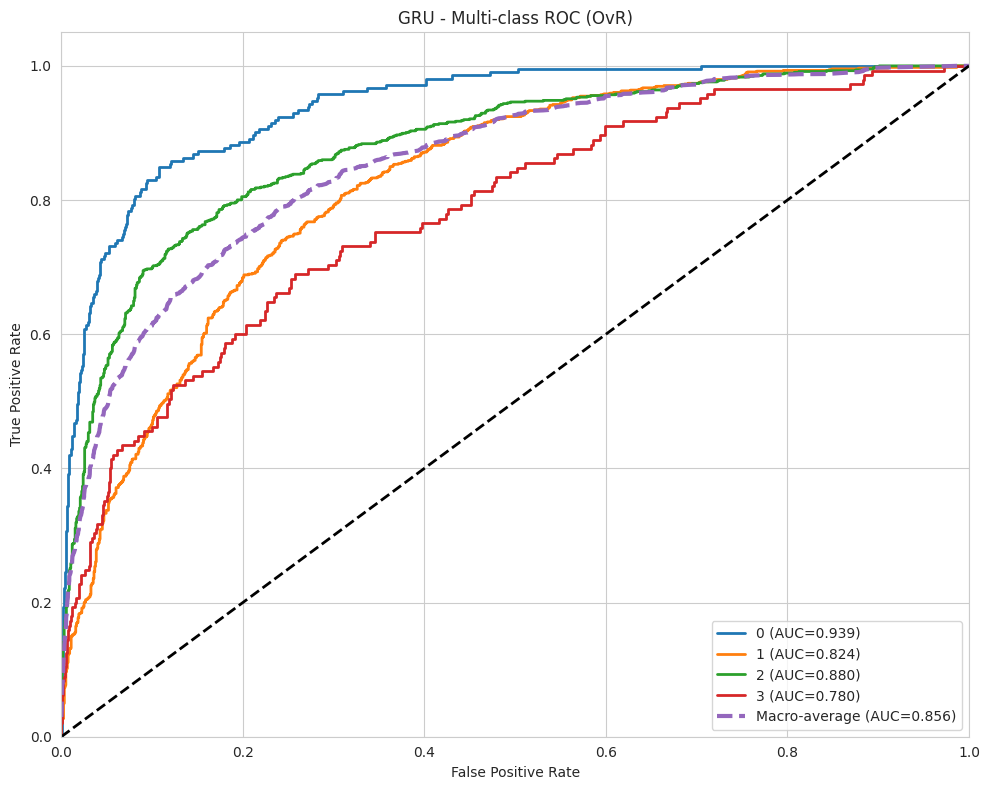

{'y_true': array([1, 1, 1, ..., 2, 3, 3]),
 'y_pred': array([1, 1, 2, ..., 1, 2, 3]),
 'y_prob': array([[3.2747336e-02, 8.1171685e-01, 9.1215232e-03, 1.4641425e-01],
        [9.1946758e-02, 6.6960114e-01, 2.3198073e-01, 6.4713014e-03],
        [1.9746819e-04, 4.7871126e-03, 9.9237400e-01, 2.6413910e-03],
        ...,
        [2.8748417e-01, 4.7684211e-01, 7.2590010e-03, 2.2841476e-01],
        [6.3244152e-05, 1.2109430e-01, 8.6575693e-01, 1.3085536e-02],
        [5.6313995e-05, 8.3512760e-04, 9.8897447e-04, 9.9811953e-01]],
       dtype=float32),
 'f1_mean': 0.7031567227404275,
 'f1_ci': (0.68370693361279, 0.7223952959054639),
 'auc_mean': 0.8555459406298452,
 'auc_ci': (0.8406015891902927, 0.8692949333194494),
 'class_names': ['0', '1', '2', '3']}

In [53]:
evaluate_pytorch_model(model, test_loader_3, device, model_name="GRU", num_classes=NUM_CLASSES, use_attention_mask=False)

## 3.3 Model Comparison

In [54]:
# ============================================================
# 3.3 Model Comparison: Load saved best models and save predictions
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import joblib
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from transformers import AlbertForSequenceClassification, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VALID_LABELS = ["very_negative", "negative", "neutral", "positive"]
NUM_CLASSES = len(VALID_LABELS)
LABEL2ID = {lbl: i for i, lbl in enumerate(VALID_LABELS)}
ID2LABEL = {i: lbl for lbl, i in LABEL2ID.items()}

def require_file(path, name):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{name} not found: {path}")
    return path

def coerce_labels_to_id_and_str(y):
    y = np.asarray(y)
    if np.issubdtype(y.dtype, np.integer):
        y_id = y.astype(int)
        y_str = np.array([ID2LABEL[i] for i in y_id], dtype=object)
        return y_id, y_str

    y_str = y.astype(str)
    uniq = set(np.unique(y_str))

    if uniq.issubset(set(VALID_LABELS)):
        y_id = np.array([LABEL2ID[s] for s in y_str], dtype=int)
        return y_id, y_str

    id_tokens = set(map(str, range(NUM_CLASSES)))
    if uniq.issubset(id_tokens):
        y_id = y_str.astype(int)
        y_str = np.array([ID2LABEL[i] for i in y_id], dtype=object)
        return y_id, y_str

    raise ValueError(f"Unrecognized labels: {sorted(list(uniq))[:20]}")

def reorder_proba_to_canonical(model_classes, proba):
    cls = np.asarray(model_classes).astype(str)
    proba = np.asarray(proba)

    id_tokens = [str(i) for i in range(NUM_CLASSES)]
    if set(cls).issubset(set(id_tokens)):
        idx = [np.where(cls == str(i))[0][0] for i in range(NUM_CLASSES)]
        return proba[:, idx]

    if set(cls).issubset(set(VALID_LABELS)):
        idx = [np.where(cls == lbl)[0][0] for lbl in VALID_LABELS]
        return proba[:, idx]

    raise ValueError(f"Unexpected model.classes_: {model_classes}")

def _get_logits(outputs):
    if hasattr(outputs, "logits"):
        return outputs.logits
    if isinstance(outputs, (tuple, list)):
        return outputs[0]
    return outputs

def predict_pytorch(model, loader, device, num_classes, use_attention_mask=True, desc="Predicting"):
    model.eval()
    model.to(device)

    all_y, all_pred, all_prob = [], [], []
    softmax = torch.nn.Softmax(dim=1)

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            if use_attention_mask:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                outputs = model(input_ids)

            logits = _get_logits(outputs)
            if logits.ndim != 2 or logits.shape[1] != num_classes:
                raise ValueError(f"Expected logits shape (batch, {num_classes}), got {tuple(logits.shape)}")

            prob = softmax(logits)
            pred = torch.argmax(prob, dim=1)

            all_y.append(labels.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            all_prob.append(prob.cpu().numpy())

    return np.concatenate(all_y), np.concatenate(all_pred), np.concatenate(all_prob)

def add_model_predictions(df_pred, prefix, pred_id, prob):
    pred_id = np.asarray(pred_id).astype(int)
    df_pred[f"{prefix}_pred_id"] = pred_id
    df_pred[f"{prefix}_pred"] = np.array([ID2LABEL[i] for i in pred_id], dtype=object)

    for j, lbl in enumerate(VALID_LABELS):
        df_pred[f"{prefix}_prob_{lbl}"] = prob[:, j]

# Reconstruct same test split.
TEXT_COLUMN = "posts"
LABEL_COLUMN = "ai_pred_label"

idx_all = np.arange(len(df))
_, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42)

df_test = df.iloc[test_idx].copy().reset_index(drop=True)
if "id" not in df_test.columns:
    df_test.insert(0, "id", df_test.index)

y_true_id, y_true_str = coerce_labels_to_id_and_str(df_test[LABEL_COLUMN].values)

df_pred = df_test[["id", TEXT_COLUMN]].copy()
df_pred = df_pred.rename(columns={TEXT_COLUMN: "text_orig"})
df_pred["true_label"] = y_true_str
df_pred["true_label_id"] = y_true_id
df_pred["split"] = "test"

# Logistic Regression
X_test_vec = X_test_tfidf_1

lr_model = joblib.load(require_file(BEST_LR_PATH, "Best LR model"))
lr_pred_id, _ = coerce_labels_to_id_and_str(lr_model.predict(X_test_vec))
lr_proba = reorder_proba_to_canonical(lr_model.classes_, lr_model.predict_proba(X_test_vec))
add_model_predictions(df_pred, "lr", lr_pred_id, lr_proba)

# Random Forest
rf_model = joblib.load(require_file(BEST_RF_PATH, "Best RF model"))
rf_pred_id, _ = coerce_labels_to_id_and_str(rf_model.predict(X_test_vec))
rf_proba = reorder_proba_to_canonical(rf_model.classes_, rf_model.predict_proba(X_test_vec))
add_model_predictions(df_pred, "rf", rf_pred_id, rf_proba)

# LightGBM
lgbm_model = joblib.load(require_file(BEST_LGBM_PATH, "Best LightGBM model"))
lgbm_pred_id, _ = coerce_labels_to_id_and_str(lgbm_model.predict(X_test_vec))
lgbm_proba = reorder_proba_to_canonical(lgbm_model.classes_, lgbm_model.predict_proba(X_test_vec))
add_model_predictions(df_pred, "lgbm", lgbm_pred_id, lgbm_proba)

# ALBERT
albert_model = AlbertForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=NUM_CLASSES,
).to(device)
albert_model.load_state_dict(
    torch.load(require_file(BEST_ALBERT_PATH, "Best ALBERT model"), map_location=device)
)

y_alb_true, y_alb_pred, y_alb_prob = predict_pytorch(
    albert_model, test_loader_2, device, NUM_CLASSES,
    use_attention_mask=True,
    desc="Predicting ALBERT"
)
if not np.array_equal(y_alb_true.astype(int), y_true_id.astype(int)):
    raise ValueError("ALBERT test_loader_2 order does not match df_test order.")
add_model_predictions(df_pred, "albert", y_alb_pred, y_alb_prob)

# BioBERT
biobert_model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
).to(device)
biobert_model.load_state_dict(
    torch.load(require_file(BEST_BIOBERT_PATH, "Best BioBERT model"), map_location=device)
)

y_bio_true, y_bio_pred, y_bio_prob = predict_pytorch(
    biobert_model, test_loader_4, device, NUM_CLASSES,
    use_attention_mask=True,
    desc="Predicting BioBERT"
)
if not np.array_equal(y_bio_true.astype(int), y_true_id.astype(int)):
    raise ValueError("BioBERT test_loader_4 order does not match df_test order.")
add_model_predictions(df_pred, "biobert", y_bio_pred, y_bio_prob)

# GRU
with open(require_file(BEST_GRU_PARAMS_PATH, "Best GRU params"), "r") as f:
    gru_params = json.load(f)

gru_model = GRUSentimentModel(
    vocab_size=int(gru_params.get("vocab_size", VOCAB_SIZE)),
    embedding_dim=int(gru_params["embedding_dim"]),
    hidden_dim=int(gru_params["hidden_dim"]),
    output_dim=NUM_CLASSES,
).to(device)
gru_model.load_state_dict(
    torch.load(require_file(BEST_GRU_PATH, "Best GRU model"), map_location=device)
)

y_gru_true, y_gru_pred, y_gru_prob = predict_pytorch(
    gru_model, test_loader_3, device, NUM_CLASSES,
    use_attention_mask=False,
    desc="Predicting GRU"
)
if not np.array_equal(y_gru_true.astype(int), y_true_id.astype(int)):
    raise ValueError("GRU test_loader_3 order does not match df_test order.")
add_model_predictions(df_pred, "gru", y_gru_pred, y_gru_prob)

save_path = os.path.join(DRIVE_PROJECT_PATH, "models_predictions_test.csv")
df_pred.to_csv(save_path, index=False)

print(f"Saved combined predictions to: {save_path}")
print("Shape:", df_pred.shape)
print("Columns:", df_pred.columns.tolist())

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Predicting ALBERT: 100%|██████████| 65/65 [00:28<00:00,  2.31it/s]
[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

Saved combined predictions to: /content/drive/MyDrive/Research_Project/Frontiers/outputs_4class/models_predictions_test.csv
Shape: (2079, 41)
Columns: ['id', 'text_orig', 'true_label', 'true_label_id', 'split', 'lr_pred_id', 'lr_pred', 'lr_prob_very_negative', 'lr_prob_negative', 'lr_prob_neutral', 'lr_prob_positive', 'rf_pred_id', 'rf_pred', 'rf_prob_very_negative', 'rf_prob_negative', 'rf_prob_neutral', 'rf_prob_positive', 'lgbm_pred_id', 'lgbm_pred', 'lgbm_prob_very_negative', 'lgbm_prob_negative', 'lgbm_prob_neutral', 'lgbm_prob_positive', 'albert_pred_id', 'albert_pred', 'albert_prob_very_negative', 'albert_prob_negative', 'albert_prob_neutral', 'albert_prob_positive', 'biobert_pred_id', 'biobert_pred', 'biobert_prob_very_negative', 'biobert_prob_negative', 'biobert_prob_neutral', 'biobert_prob_positive', 'gru_pred_id', 'gru_pred', 'gru_prob_very_negative', 'gru_prob_negative', 'gru_prob_neutral', 'gru_prob_positive']


In [55]:
# ============================================================
# 3.3 Model Comparison: Pairwise McNemar tests
# ============================================================

import os
import numpy as np
import pandas as pd
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

pred_path = os.path.join(DRIVE_PROJECT_PATH, "models_predictions_test.csv")
df_cmp = pd.read_csv(pred_path)

y_true = df_cmp["true_label_id"].astype(int).values

model_column_map = {
    "LogReg": "lr_pred_id",
    "RandomForest": "rf_pred_id",
    "LGBM": "lgbm_pred_id",
    "ALBERT": "albert_pred_id",
    "BioBERT": "biobert_pred_id",
    "GRU": "gru_pred_id",
}

model_preds = {}
for model_name, column in model_column_map.items():
    if column in df_cmp.columns:
        model_preds[model_name] = df_cmp[column].astype(int).values
    else:
        print(f"Missing model prediction column, skipped: {model_name} / {column}")

def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        p1 = np.asarray(model_preds[m1])
        p2 = np.asarray(model_preds[m2])

        m1_correct = p1 == y_true
        m2_correct = p2 == y_true

        a = int(np.sum(m1_correct & m2_correct))
        b = int(np.sum(m1_correct & ~m2_correct))
        c = int(np.sum(~m1_correct & m2_correct))
        d = int(np.sum(~m1_correct & ~m2_correct))

        table = np.array([[a, b], [c, d]])
        res = mcnemar(table, exact=False, correction=True)

        if b > c:
            direction = f"{m1} > {m2}"
        elif c > b:
            direction = f"{m2} > {m1}"
        else:
            direction = "Tie discordant"

        results.append({
            "Model 1": m1,
            "Model 2": m2,
            "a_both_correct": a,
            "b_m1_only_correct": b,
            "c_m2_only_correct": c,
            "d_both_wrong": d,
            "Statistic": res.statistic,
            "Raw p-value": res.pvalue,
            "Direction": direction,
        })

    df_out = pd.DataFrame(results)

    if not df_out.empty:
        _, p_corr, _, _ = multipletests(df_out["Raw p-value"].values, method=method)
        df_out["Corrected p-value"] = p_corr
        df_out["Significant"] = np.where(df_out["Corrected p-value"] < 0.05, "Yes", "No")
        df_out["Winner"] = np.where(df_out["Significant"] == "Yes", df_out["Direction"], "Inconclusive")

    return df_out

df_mcnemar = mcnemar_pairwise(y_true, model_preds, method="bonferroni")

mcnemar_path = os.path.join(DRIVE_PROJECT_PATH, "pairwise_mcnemar.csv")
df_mcnemar.to_csv(mcnemar_path, index=False)

print(f"Saved McNemar results to: {mcnemar_path}")
print(df_mcnemar)

Saved McNemar results to: /content/drive/MyDrive/Research_Project/Frontiers/outputs_4class/pairwise_mcnemar.csv
         Model 1       Model 2  a_both_correct  b_m1_only_correct  \
0         LogReg  RandomForest            1230                246   
1         LogReg          LGBM            1329                147   
2         LogReg        ALBERT            1278                198   
3         LogReg       BioBERT            1272                204   
4         LogReg           GRU            1168                308   
5   RandomForest          LGBM            1278                155   
6   RandomForest        ALBERT            1247                186   
7   RandomForest       BioBERT            1254                179   
8   RandomForest           GRU            1142                291   
9           LGBM        ALBERT            1286                229   
10          LGBM       BioBERT            1300                215   
11          LGBM           GRU            1196              